# Import libs

In [53]:
# Install dependencies if you haven't already:
# !pip install SimpleITK matplotlib numpy

import SimpleITK as sitk
import matplotlib.pyplot as plt
import numpy as np
import os
import json
import matplotlib.image as mpimg
import glob
import cv2

# Ensure plots render inline in the notebook
%matplotlib inline

# Config Paths

In [40]:
mri_base_path = "/projetos/multiparametrica/DICOM/"
masks_base_path = "/home/heitor/Documents/masks/"

In [41]:
"""
patient_id: [EC_Study_Number, Num_DICOM]
"""

mri_dataset_info = {
    '277141': ['15', 200],
    '075197': ['14', 240], 
    '147230': ['14', 160], 
    '454328': ['11', 220], 
    '897528': ['10', 200], 
    '085837': ['17', 200], 
    '500677': ['20', 200], 
    '308512': ['14', 160]    
}

# Reading masks

## Functions

In [64]:
def get_patient_files(base_path: str, patient_id: str, study_num: str) -> dict:
    """Constructs dictionary of available files for a given patient."""
    patient_folder = os.path.join(base_path, patient_id)
    if not os.path.exists(patient_folder):
        return {}

    files = {
        'Original_Mask': os.path.join(patient_folder, 'Segmentation.seg.nrrd'),
        'Fat_Mask': os.path.join(patient_folder, 'Fat_Segmentation.seg.nrrd'),
        'Frame_19': os.path.join(patient_folder, f'{study_num} MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd'),
        'Sequence_4D': os.path.join(patient_folder, f'{study_num} MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd'),
        'JSON': os.path.join(patient_folder, 'Volume rendering ROI.mrk.json')
    }

    print(files)    
    
    # Dynamically find the PNG scene (ignoring date prefix)
    png_files = glob.glob(os.path.join(patient_folder, '*Scene.png'))
    if png_files:
        files['Scene_PNG'] = png_files[0]
        
    return {k: v for k, v in files.items() if os.path.exists(v)}


def print_nrrd_metadata(file_path: str, title: str) -> np.ndarray:
    """Reads a .nrrd file, prints its metadata, and returns the numpy array."""
    itk_img = sitk.ReadImage(file_path)
    img_array = sitk.GetArrayFromImage(itk_img)
    
    print(f"\n--- Metadata: {title} ---")
    print(f"Path: {os.path.basename(file_path)}")
    print(f"Shape: {img_array.shape}")
    print(f"Spacing: {itk_img.GetSpacing()}")
    
    if "Mask" in title:
        print(f"Unique Labels: {np.unique(img_array)}")
        
    return img_array


def plot_3d_grid(array: np.ndarray, title: str):
    """Plots a grid for a 3D array (Slices, Height, Width)."""
    num_slices = array.shape[0]
    cols = 4
    rows = int(np.ceil(num_slices / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(15, 3 * rows))
    axes = axes.flatten()

    for i in range(len(axes)):
        if i < num_slices:
            axes[i].imshow(array[i, :, :], cmap='gray', interpolation='nearest')
            axes[i].set_title(f"Slice {i+1}")
            axes[i].axis('off')
        else:
            axes[i].axis('off')

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()


def plot_2d_image(file_path: str, title: str):
    """Plots a standard 2D image file (like .png)."""
    img = mpimg.imread(file_path)
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()

In [67]:
def process_patient(patient_id: str, study_num: str):
    """Main workflow to process and plot a single patient's files."""
    print(f"========== Processing Patient: {patient_id} ==========")
    patient_files = get_patient_files(masks_base_path, patient_id, study_num)
    
    if not patient_files:
        print(f"Folder or files not found for {patient_id}.")
        return

    print(patient_files)
    # 1. Process and Plot the Mask (3D)
    if 'Original_Mask' in patient_files:
        mask_array = print_nrrd_metadata(patient_files['Original_Mask'], "3D Segmentation Mask")
        plot_3d_grid(mask_array, f"Patient {patient_id} - Mask")
    else:
        print("Mask was not in the patient files")

    # 2. Process and Plot the Fat Mask (3D)
    if 'Fat_Mask' in patient_files:
        fat_mask_array = print_nrrd_metadata(patient_files['Fat_Mask'], "3D Segmentation Fat Mask")
        plot_3d_grid(fat_mask_array, f"Patient {patient_id} - Fat Mask")

    # # 3. Process and Plot Frame 19 (3D)
    # if 'Frame_19' in patient_files:
    #     frame_array = print_nrrd_metadata(patient_files['Frame_19'], "Frame 19 (Peak Diastole)")
    #     plot_3d_grid(frame_array, f"Patient {patient_id} - Frame 19 MRI")

    # # 4. Process and Plot 4D Sequence (Extracting First Frame to avoid clutter)
    # if 'Sequence_4D' in patient_files:
    #     seq_array = print_nrrd_metadata(patient_files['Sequence_4D'], "4D MRI Sequence")
    #     first_frame = seq_array[0] # Grab just the first timestamp (Z, Y, X)
    #     plot_3d_grid(first_frame, f"Patient {patient_id} - 4D Sequence (Time Frame 1)")

    # # 5. Plot Scene PNG
    # if 'Scene_PNG' in patient_files:
    #     print(f"\n--- Image: 3D Slicer Scene ---")
    #     plot_2d_image(patient_files['Scene_PNG'], f"Patient {patient_id} - Slicer View")

## Execution

========== Processing Patient: 277141 ==========

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7617000000000002, 0.7617, 10.000047379523561)
Unique Labels: [0 1 2]


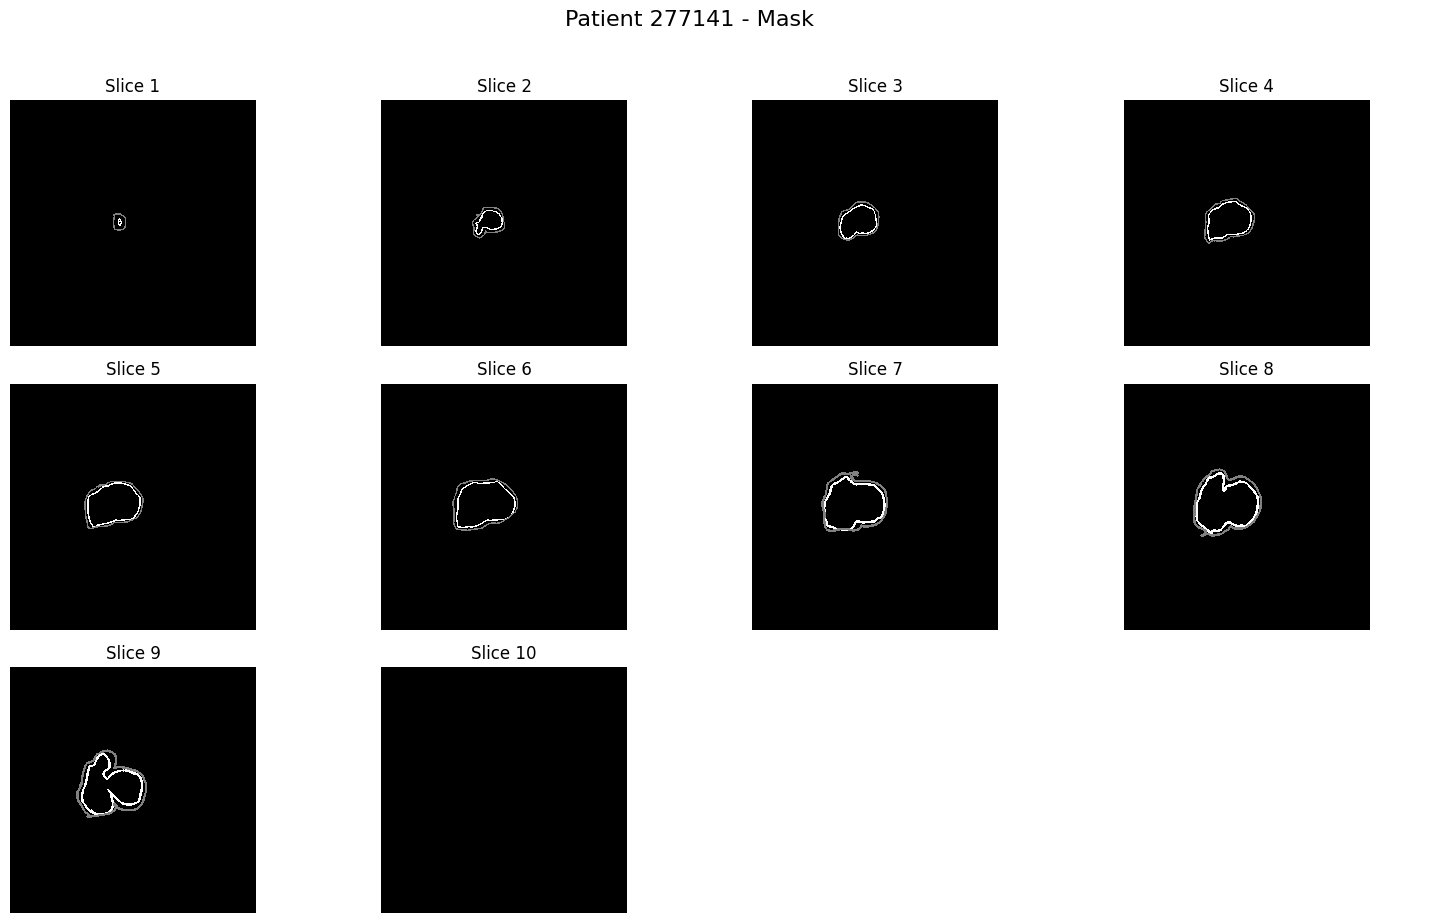


--- Metadata: Frame 19 (Peak Diastole) ---
Path: 15 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd
Shape: (10, 512, 512)
Spacing: (0.7617000000000002, 0.7617, 10.00004737952356)


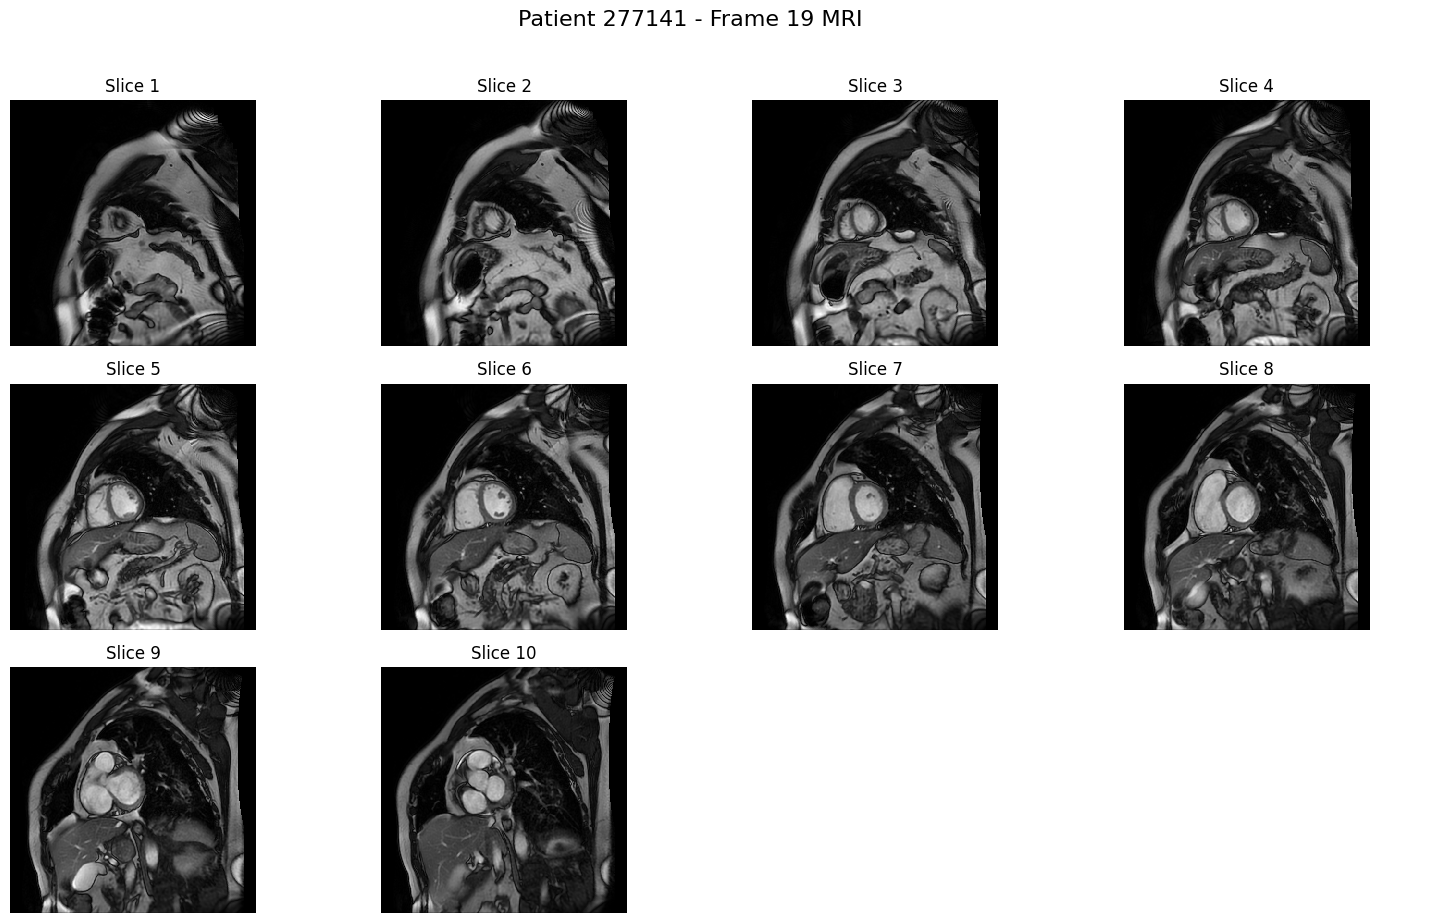


--- Image: 3D Slicer Scene ---


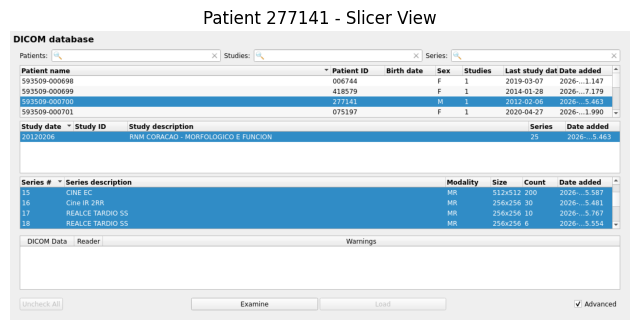

========== Processing Patient: 075197 ==========

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (12, 512, 512)
Spacing: (0.8594000000000002, 0.8594000000000002, 9.999964658268128)
Unique Labels: [0 1 2]


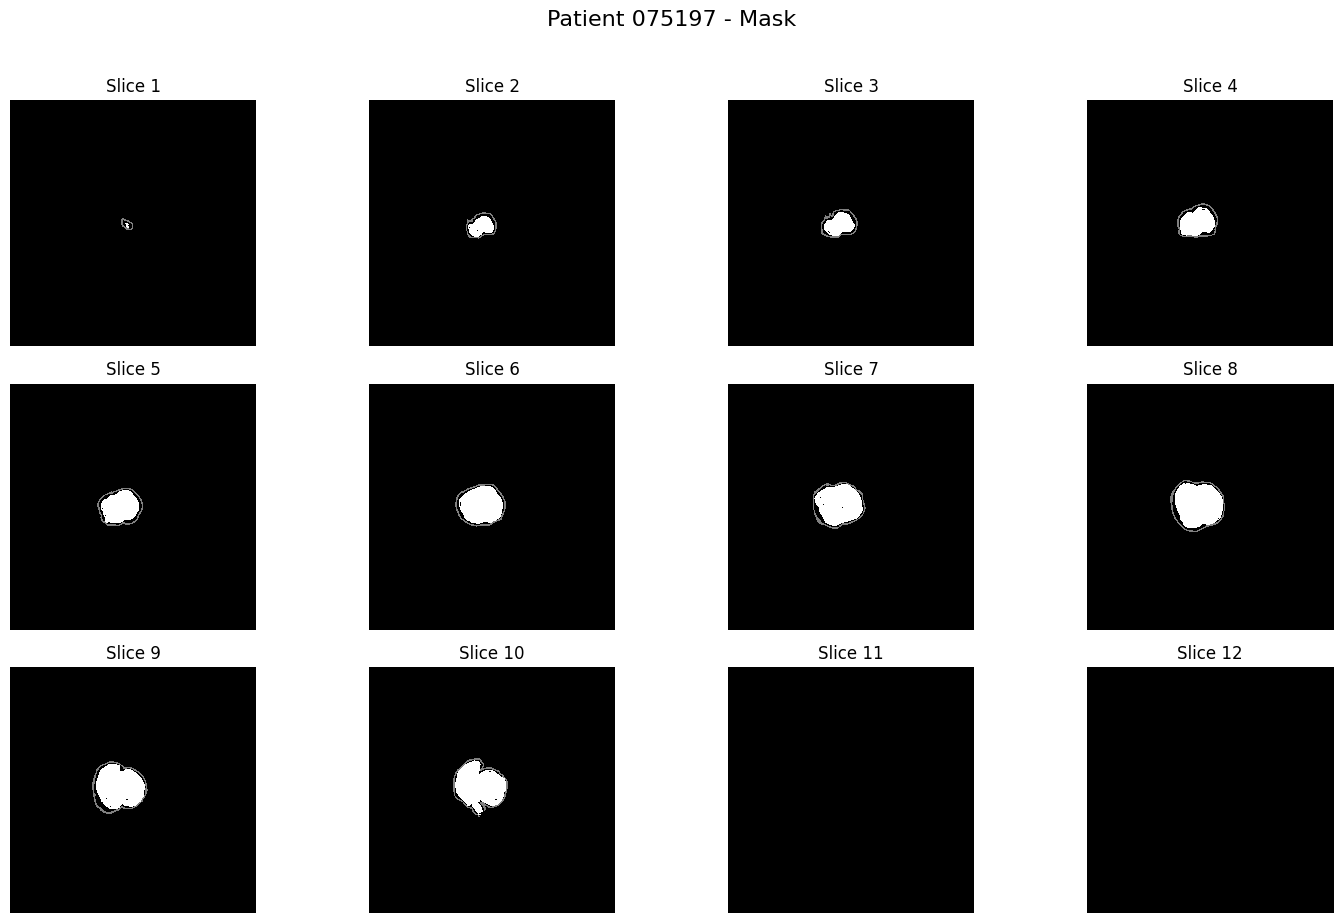


--- Image: 3D Slicer Scene ---


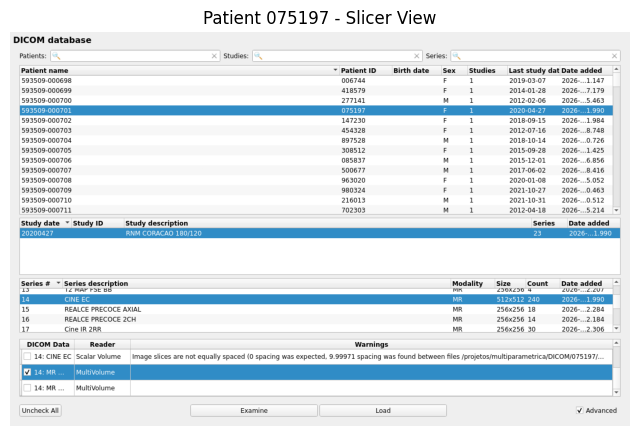

========== Processing Patient: 147230 ==========

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (8, 512, 512)
Spacing: (0.7813000000000001, 0.7813000000000001, 10.000012126641721)
Unique Labels: [0 1 2]


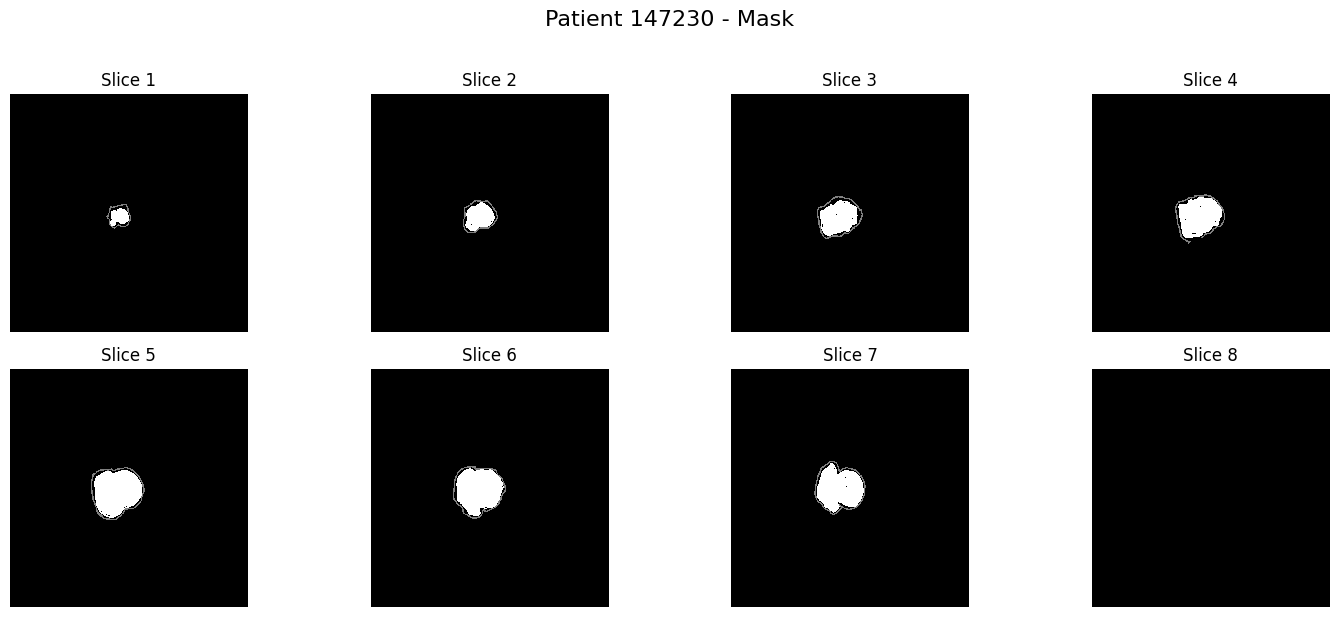


--- Metadata: Frame 19 (Peak Diastole) ---
Path: 14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd
Shape: (8, 512, 512)
Spacing: (0.7813000000000001, 0.7813000000000001, 10.000012126641721)


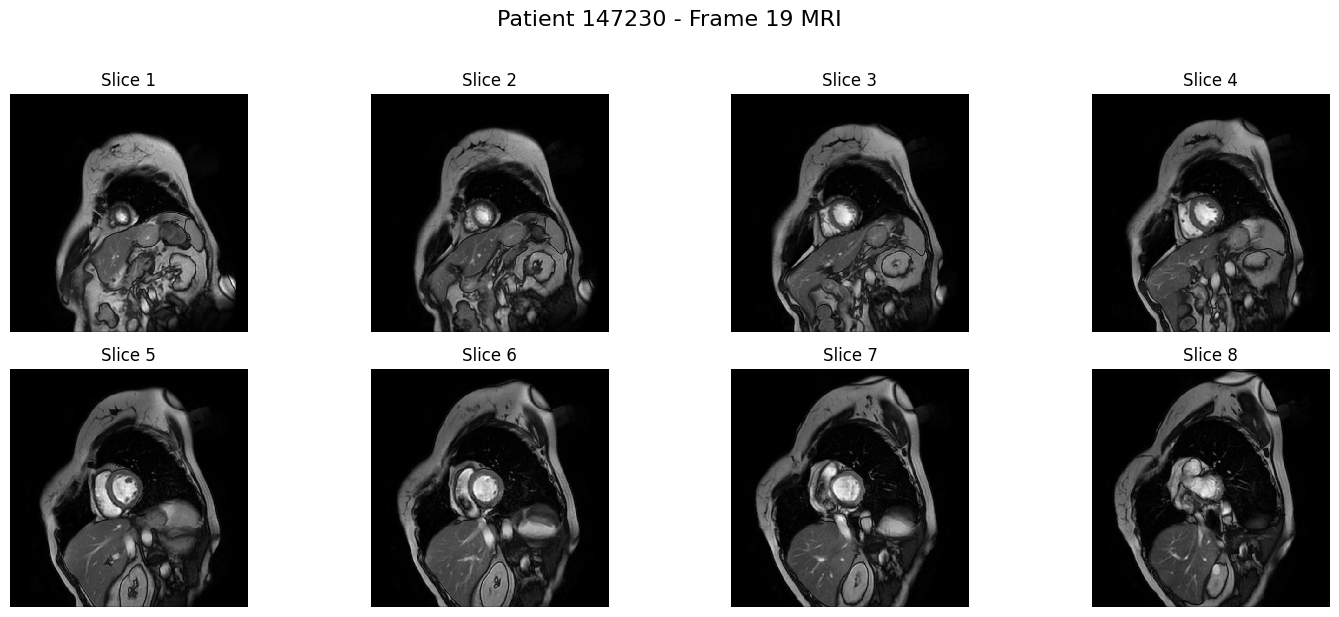


--- Image: 3D Slicer Scene ---


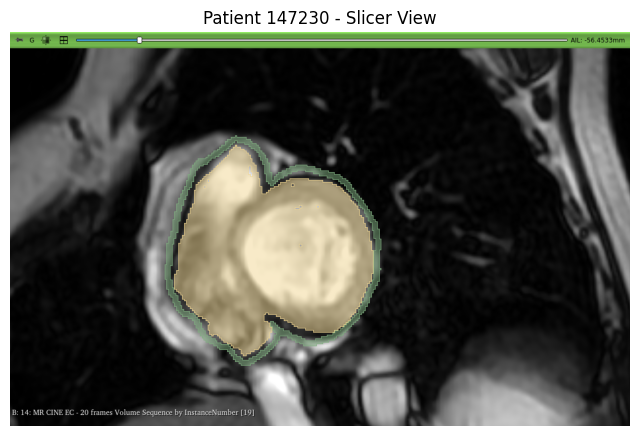

========== Processing Patient: 454328 ==========

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7031, 0.7031000000000003, 10.00002299195505)
Unique Labels: [0 1 2]


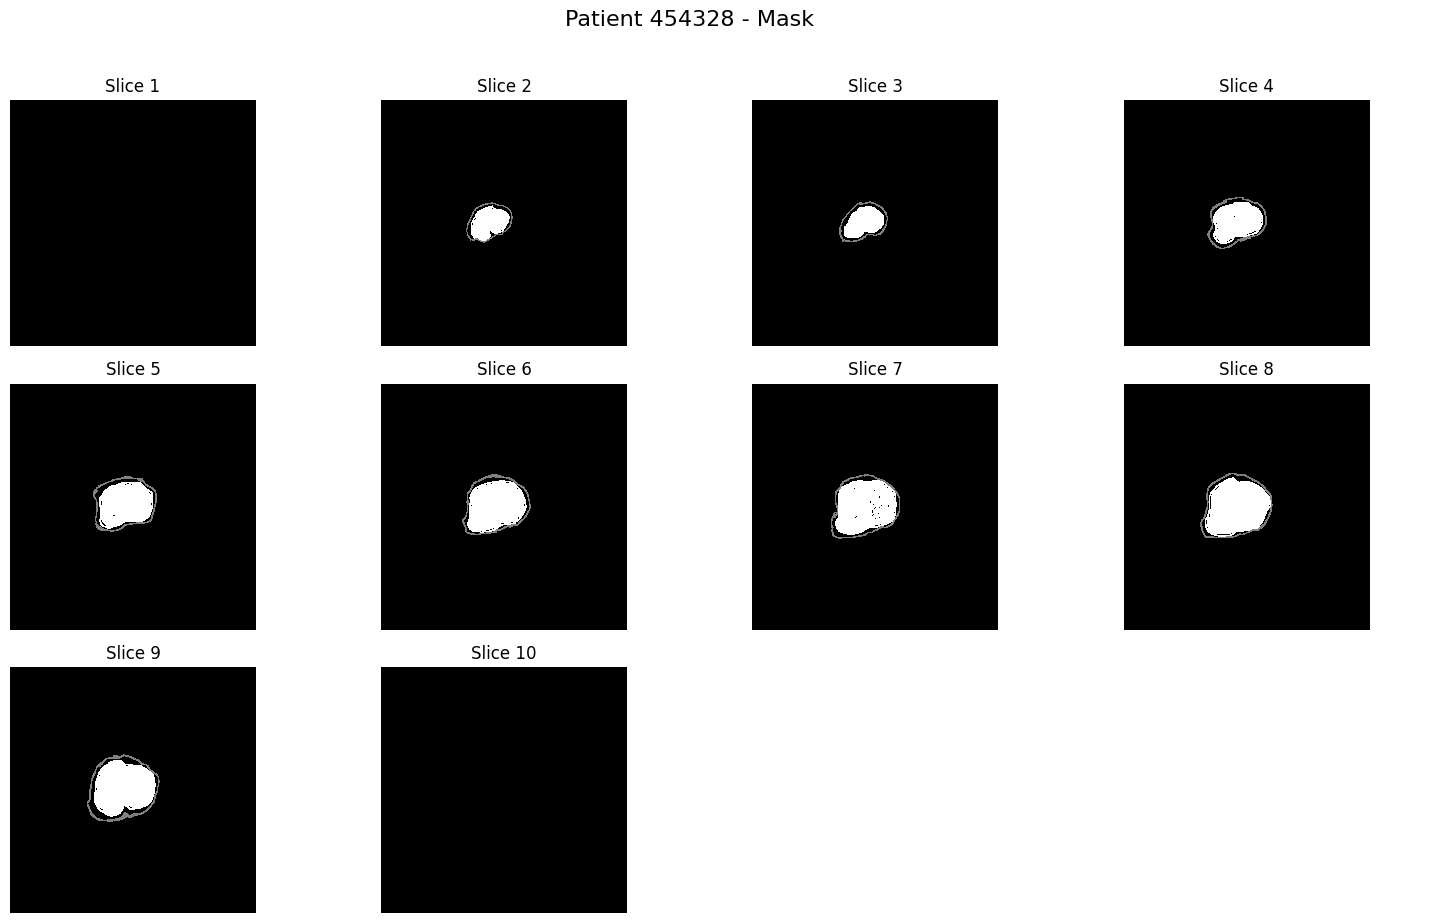


--- Image: 3D Slicer Scene ---


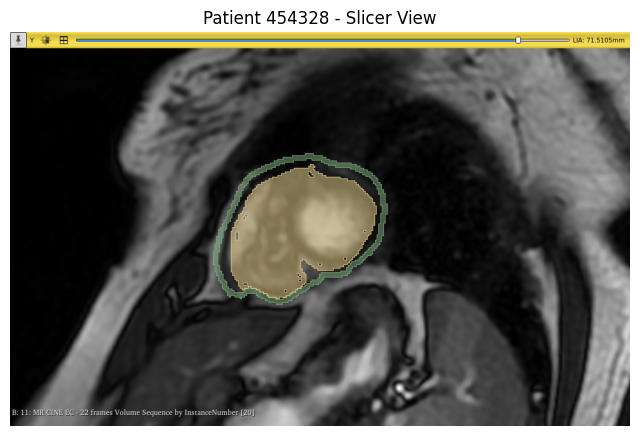

========== Processing Patient: 897528 ==========

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.8203000000000001, 0.8202999999999999, 9.999984397088133)
Unique Labels: [0 1 2]


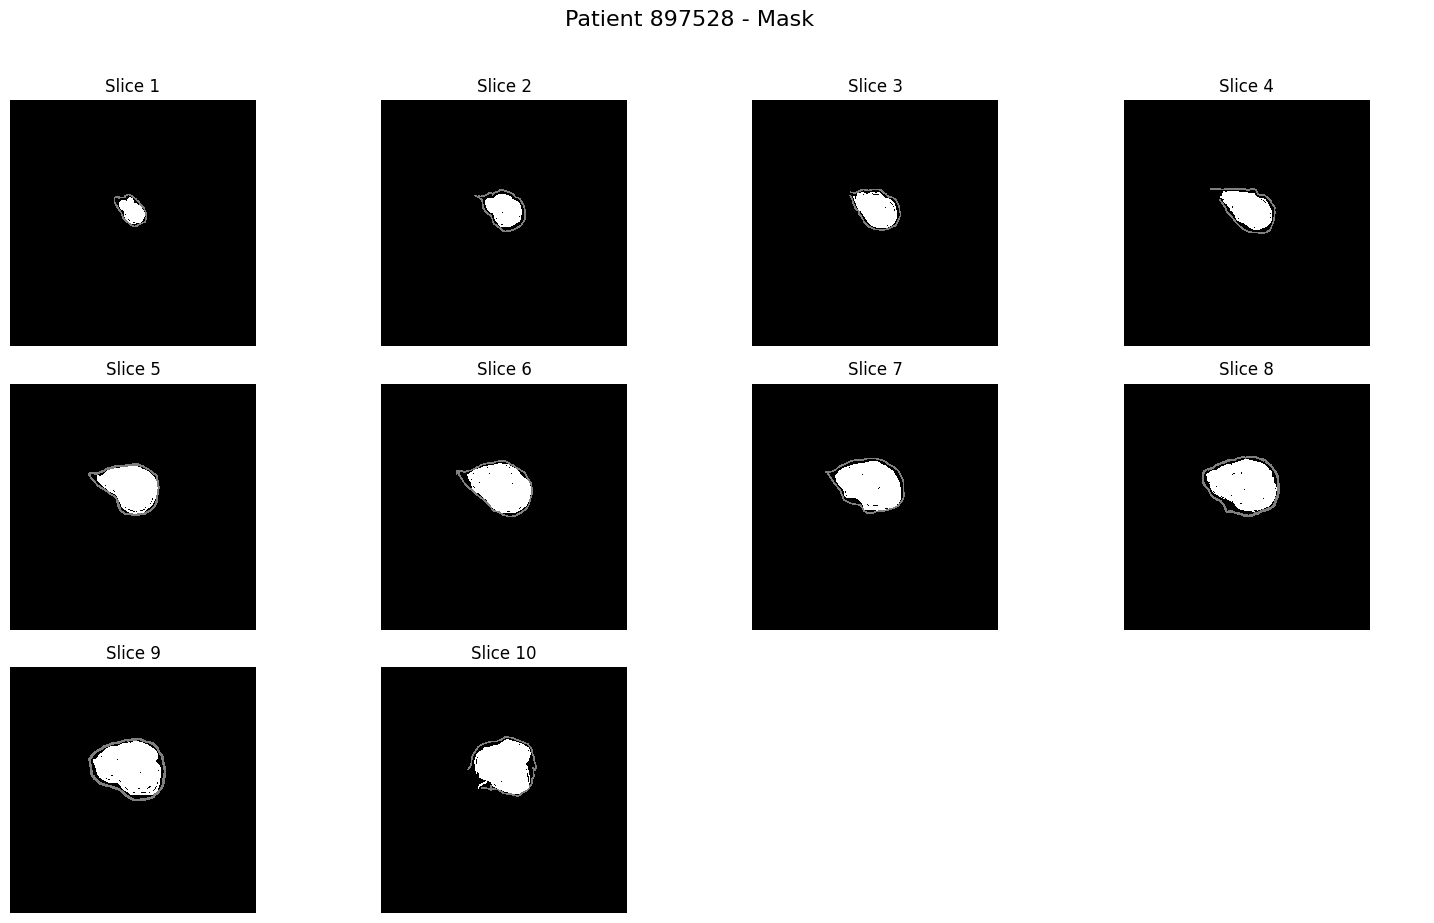


--- Metadata: Frame 19 (Peak Diastole) ---
Path: 10 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd
Shape: (10, 512, 512)
Spacing: (0.8203000000000001, 0.8202999999999999, 9.999984397088133)


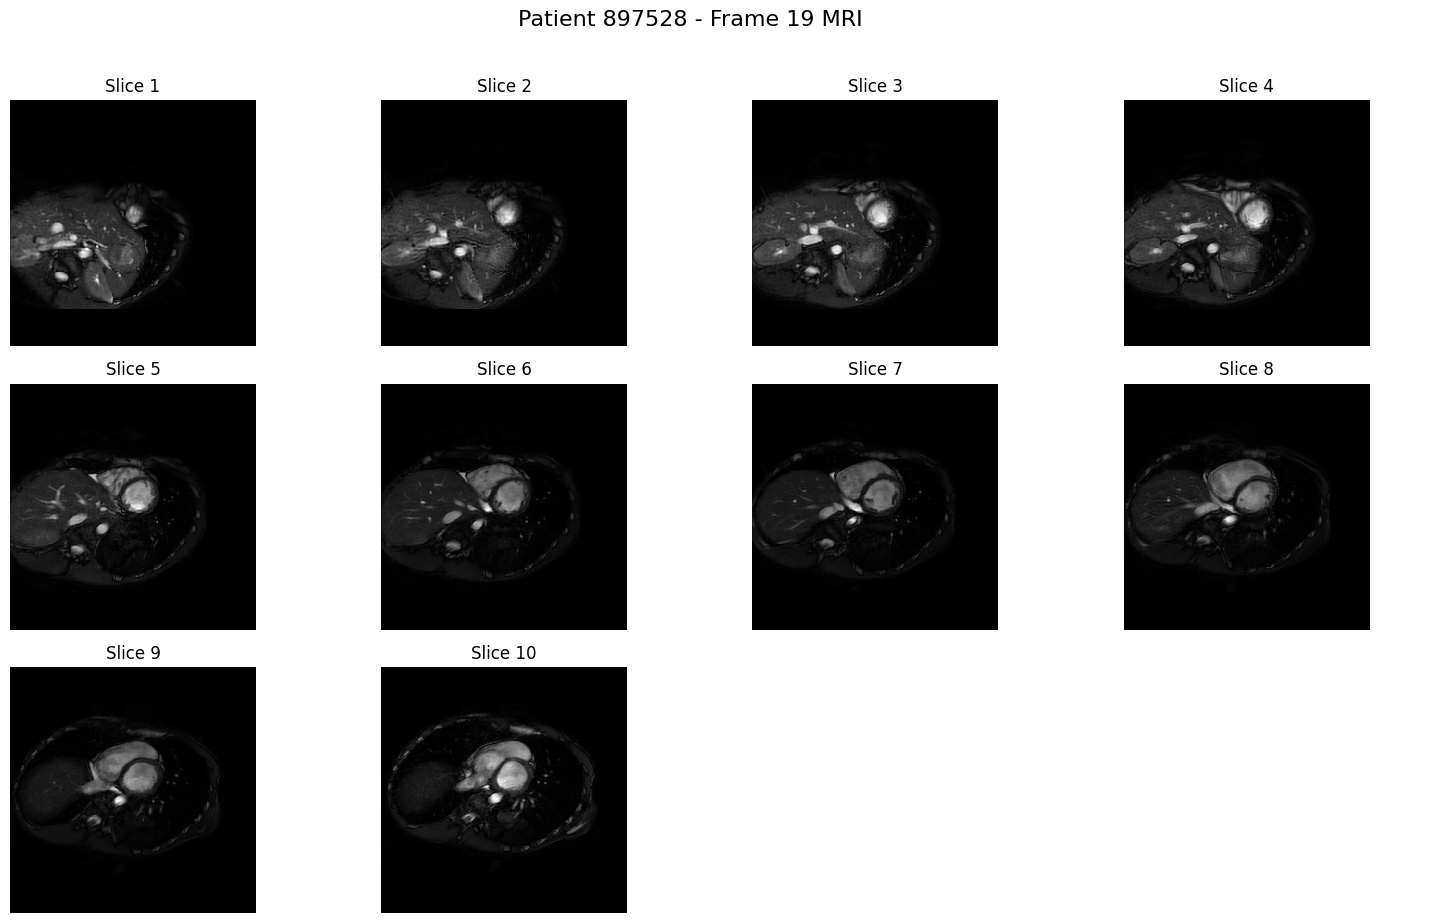


--- Image: 3D Slicer Scene ---


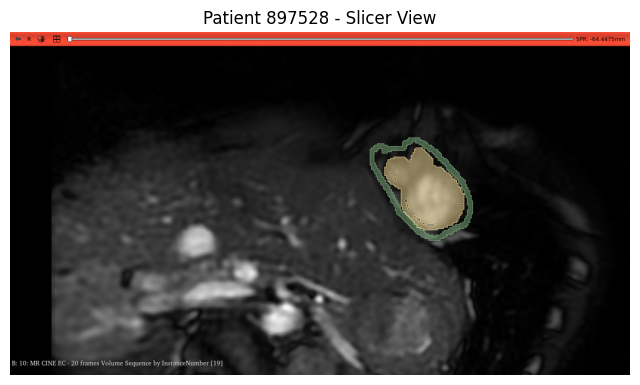

========== Processing Patient: 085837 ==========

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7813, 0.7813000000000001, 10.000066821900198)
Unique Labels: [0 1 2]


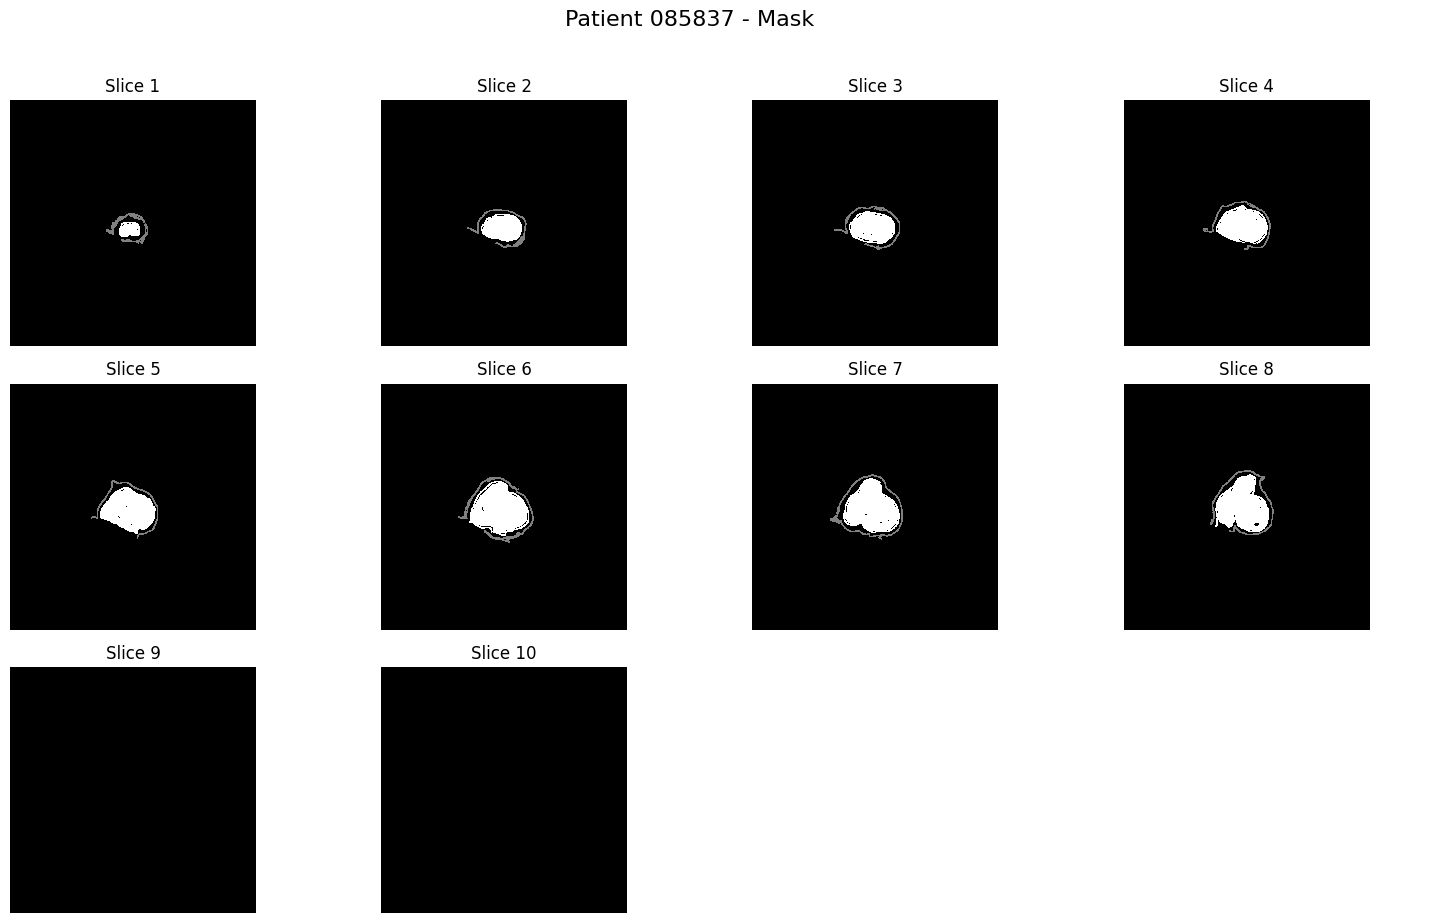


--- Image: 3D Slicer Scene ---


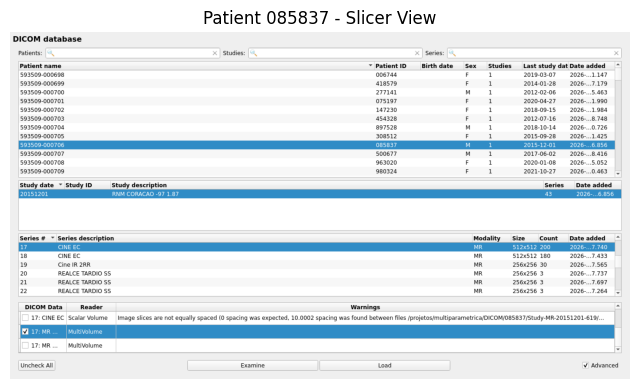

========== Processing Patient: 500677 ==========

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7031, 0.7031, 10.00005195942674)
Unique Labels: [0 1 2]


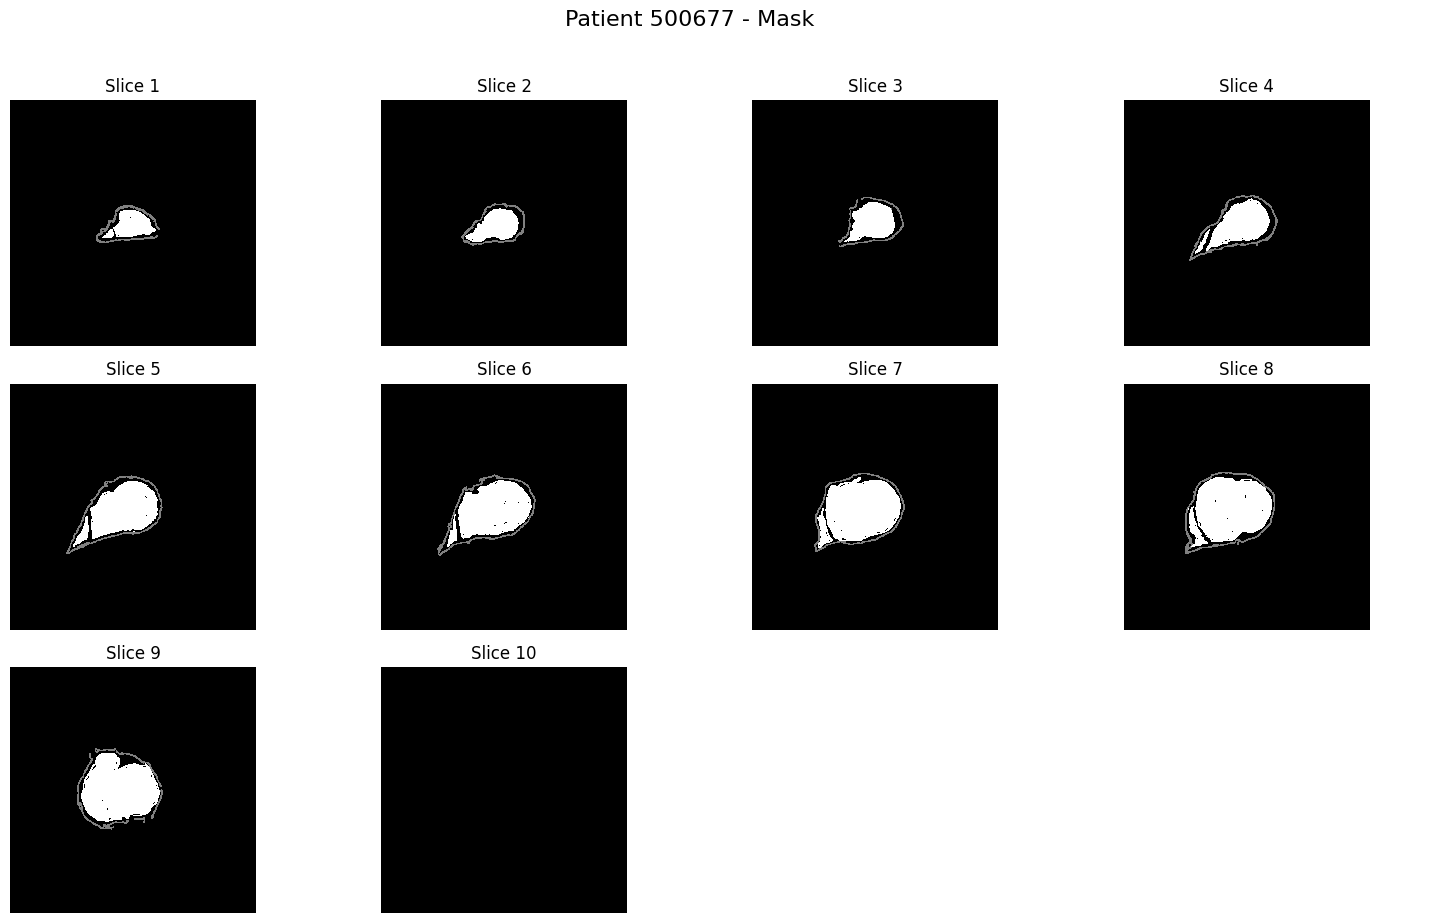


--- Image: 3D Slicer Scene ---


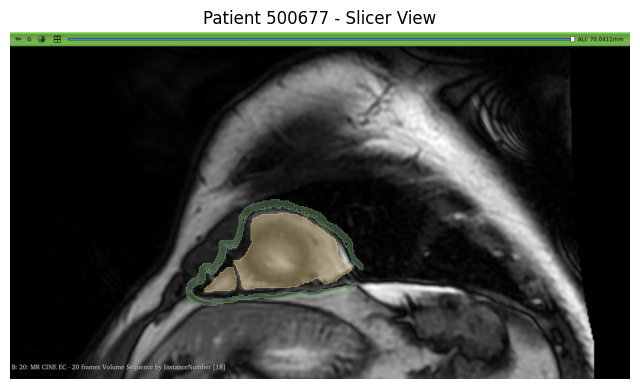

========== Processing Patient: 308512 ==========

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (8, 512, 512)
Spacing: (0.8594000000000002, 0.8594000000000003, 10.000002646132303)
Unique Labels: [0 1 2]


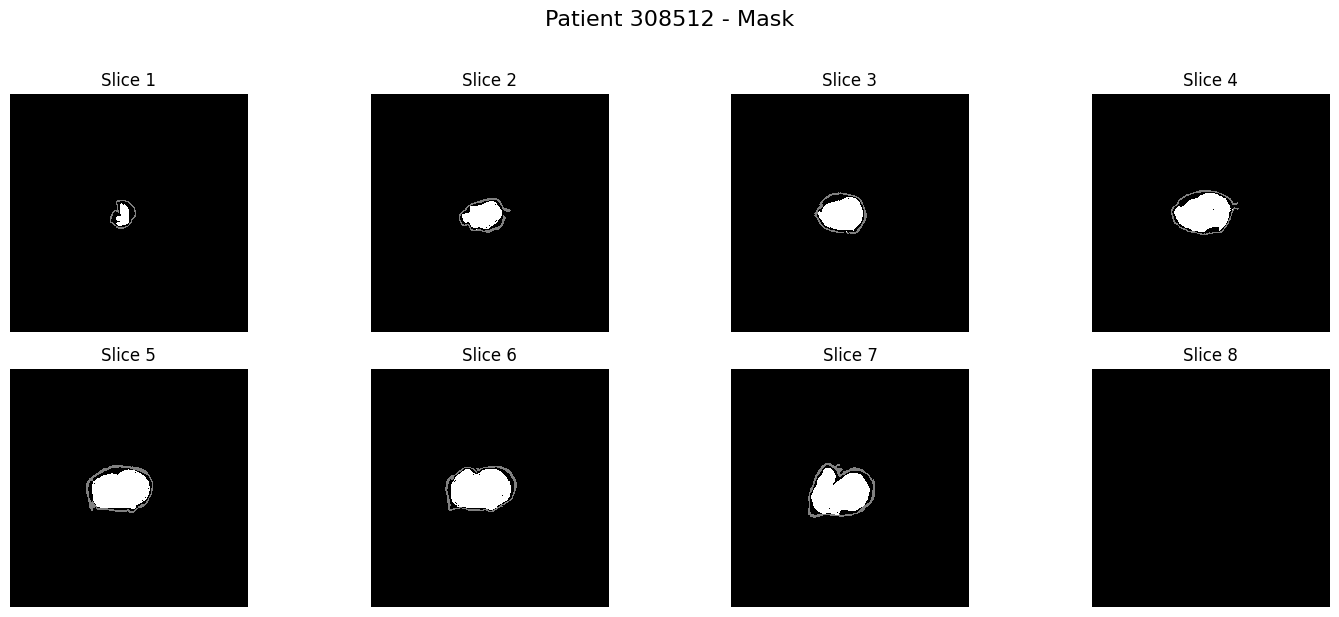


--- Metadata: Frame 19 (Peak Diastole) ---
Path: 14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd
Shape: (8, 512, 512)
Spacing: (0.8594000000000002, 0.8594000000000003, 10.000002646132303)


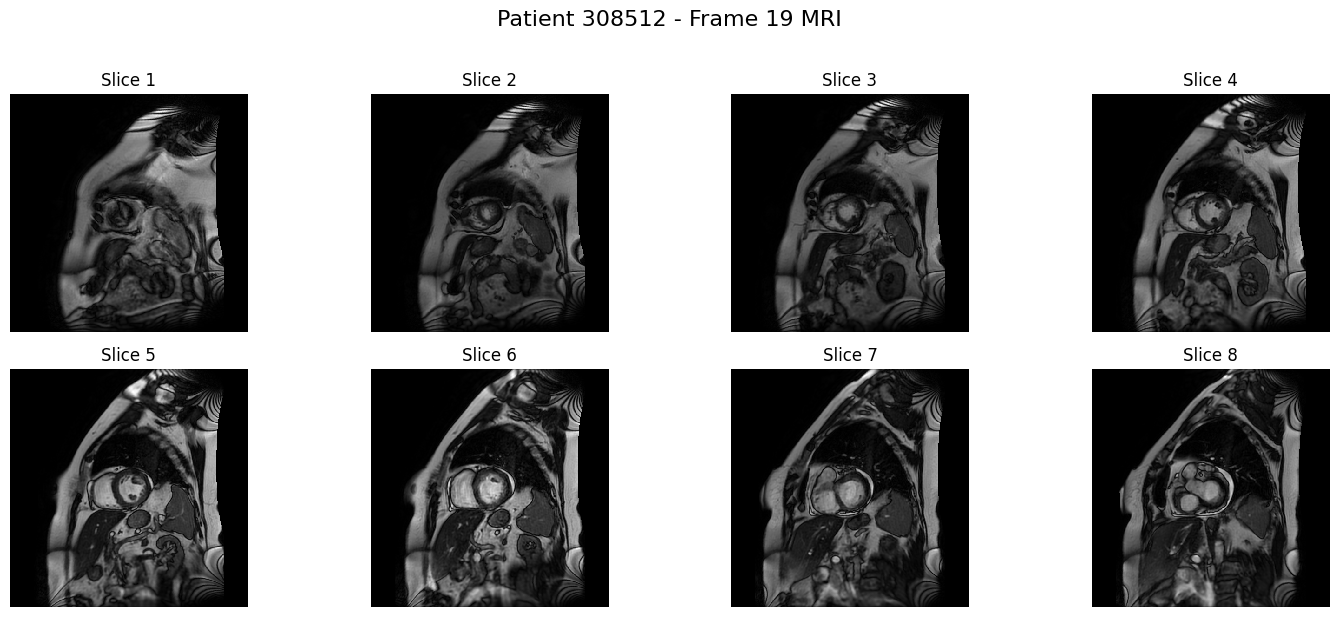


--- Image: 3D Slicer Scene ---


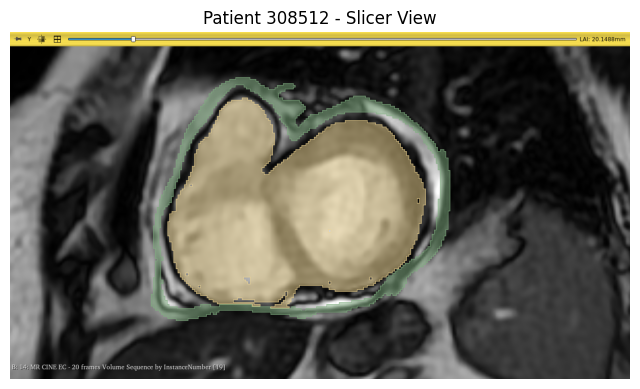

In [51]:
# Test it on a single patient
for (patient, (study, num_dcm)) in mri_dataset_info.items():    
    process_patient(patient, study)

# Extract fat mask

## Functions

In [54]:
def extract_fat_mask_procedural(slice_mask: np.ndarray) -> np.ndarray:
    if not np.any(slice_mask == 1) or not np.any(slice_mask == 2):
        return np.zeros_like(slice_mask, dtype=np.uint8)

    outer_line = (slice_mask == 1).astype(np.uint8) * 255
    inner_region = (slice_mask == 2).astype(np.uint8) * 255

    inner_filled = np.zeros_like(slice_mask, dtype=np.uint8)
    contours_inner, _ = cv2.findContours(inner_region, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cv2.drawContours(inner_filled, contours_inner, -1, 1, thickness=cv2.FILLED)

    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    dilated_outer = cv2.dilate(outer_line, kernel, iterations=2)
    
    outer_filled = np.zeros_like(slice_mask, dtype=np.uint8)
    contours_outer, _ = cv2.findContours(dilated_outer, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    if contours_outer:
        largest_outer_contour = max(contours_outer, key=cv2.contourArea)
        cv2.drawContours(outer_filled, [largest_outer_contour], -1, 1, thickness=cv2.FILLED)
    
    outer_filled = cv2.erode(outer_filled, kernel, iterations=2)
    fat_mask = cv2.subtract(outer_filled, inner_filled)
    
    return fat_mask

def process_patient_fat_3d(mask_3d: np.ndarray) -> np.ndarray:
    fat_mask_3d = np.zeros_like(mask_3d, dtype=np.uint8)
    for i in range(mask_3d.shape[0]):
        fat_mask_3d[i] = extract_fat_mask_procedural(mask_3d[i])
    return fat_mask_3d  

In [68]:
# ==========================================
# 3. SAVING LOGIC (New)
# ==========================================
def process_and_save_dataset():
    print("Starting Batch Extraction and Save...\n")
    
    for patient_id, (study_num, _) in mri_dataset_info.items():
        patient_folder = os.path.join(masks_base_path, patient_id)
        original_mask_path = os.path.join(patient_folder, 'Segmentation.seg.nrrd')
        
        # Name for the new output file
        new_mask_path = os.path.join(patient_folder, 'Fat_Segmentation.seg.nrrd')
        
        if not os.path.exists(original_mask_path):
            print(f"❌ Skipping {patient_id}: Original mask not found.")
            continue
            
        print(f"⚙️ Processing {patient_id}...")
        
        # 1. Read the original ITK Image and convert to array
        original_itk_img = sitk.ReadImage(original_mask_path)
        original_array = sitk.GetArrayFromImage(original_itk_img)
        
        # 2. Extract the fat mask
        fat_mask_array = process_patient_fat_3d(original_array)
        
        # 3. Convert the NumPy array back to a SimpleITK Image
        fat_itk_img = sitk.GetImageFromArray(fat_mask_array)
        
        # 4. Copy crucial spatial metadata (Spacing, Origin, Direction)
        fat_itk_img.CopyInformation(original_itk_img)
        
        # 5. Save the new image to disk
        sitk.WriteImage(fat_itk_img, new_mask_path)
        
        print(f"   ✅ Saved to: {new_mask_path}")

    print("\n🎉 Batch processing complete!")

## Executions

In [69]:
# ==========================================
# 4. EXECUTION
# ==========================================
process_and_save_dataset()

Starting Batch Extraction and Save...

⚙️ Processing 277141...
   ✅ Saved to: /home/heitor/Documents/masks/277141/Fat_Segmentation.seg.nrrd
⚙️ Processing 075197...
   ✅ Saved to: /home/heitor/Documents/masks/075197/Fat_Segmentation.seg.nrrd
⚙️ Processing 147230...
   ✅ Saved to: /home/heitor/Documents/masks/147230/Fat_Segmentation.seg.nrrd
⚙️ Processing 454328...
   ✅ Saved to: /home/heitor/Documents/masks/454328/Fat_Segmentation.seg.nrrd
⚙️ Processing 897528...
   ✅ Saved to: /home/heitor/Documents/masks/897528/Fat_Segmentation.seg.nrrd
⚙️ Processing 085837...
   ✅ Saved to: /home/heitor/Documents/masks/085837/Fat_Segmentation.seg.nrrd
⚙️ Processing 500677...
   ✅ Saved to: /home/heitor/Documents/masks/500677/Fat_Segmentation.seg.nrrd
⚙️ Processing 308512...
   ✅ Saved to: /home/heitor/Documents/masks/308512/Fat_Segmentation.seg.nrrd

🎉 Batch processing complete!


========== Processing Patient: 277141 ==========
{'Original_Mask': '/home/heitor/Documents/masks/277141/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/277141/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/277141/15 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/277141/15 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/277141/Volume rendering ROI.mrk.json'}
{'Original_Mask': '/home/heitor/Documents/masks/277141/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/277141/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/277141/15 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/277141/15 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/277141/Volume rendering ROI.mrk.json', '

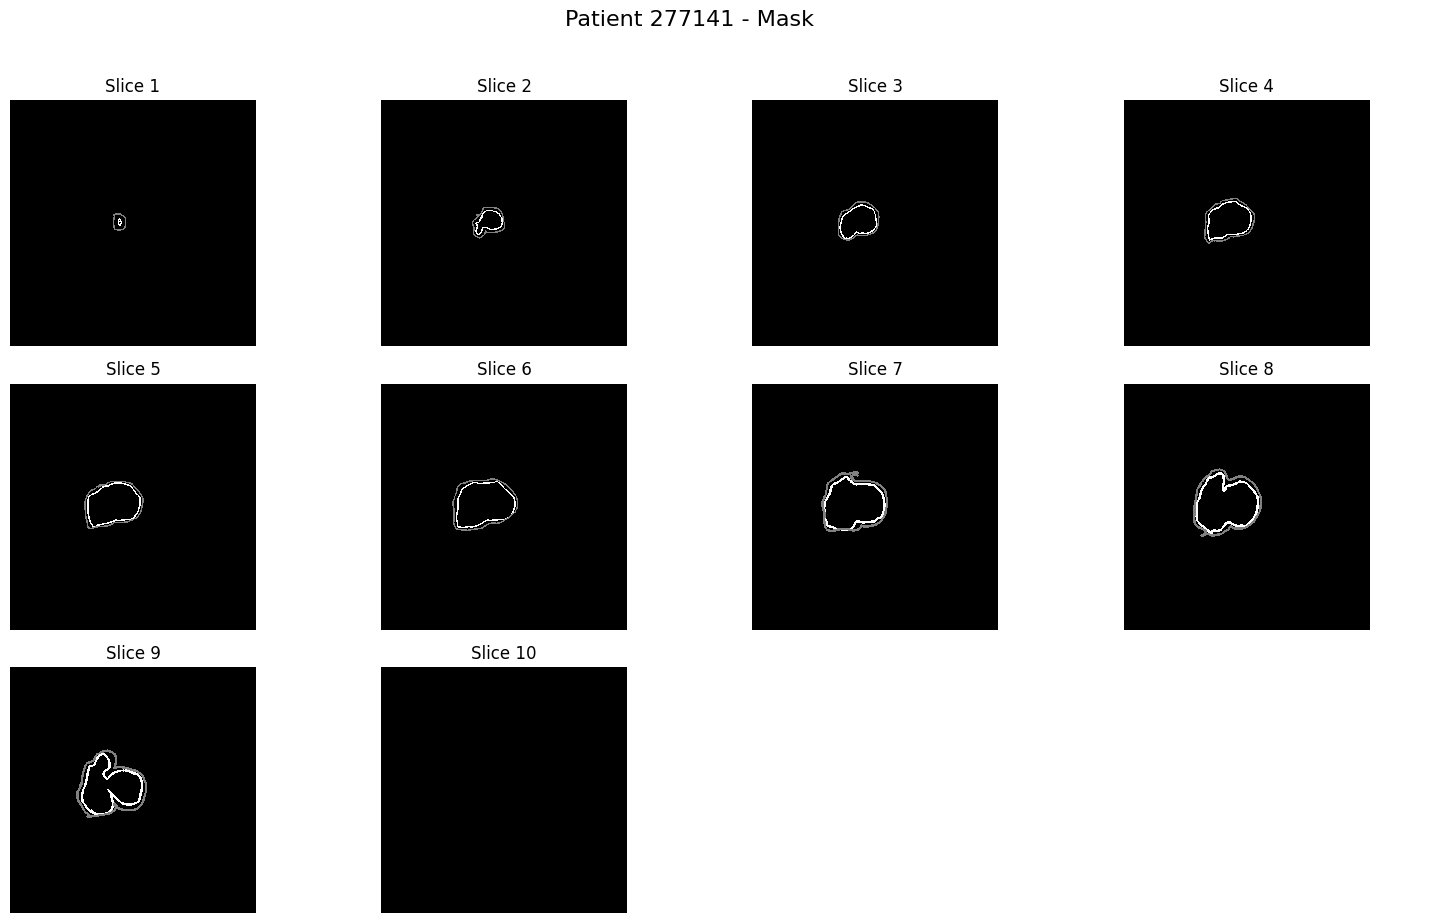


--- Metadata: 3D Segmentation Fat Mask ---
Path: Fat_Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7617000000000002, 0.7617, 10.00004737952356)
Unique Labels: [0 1]


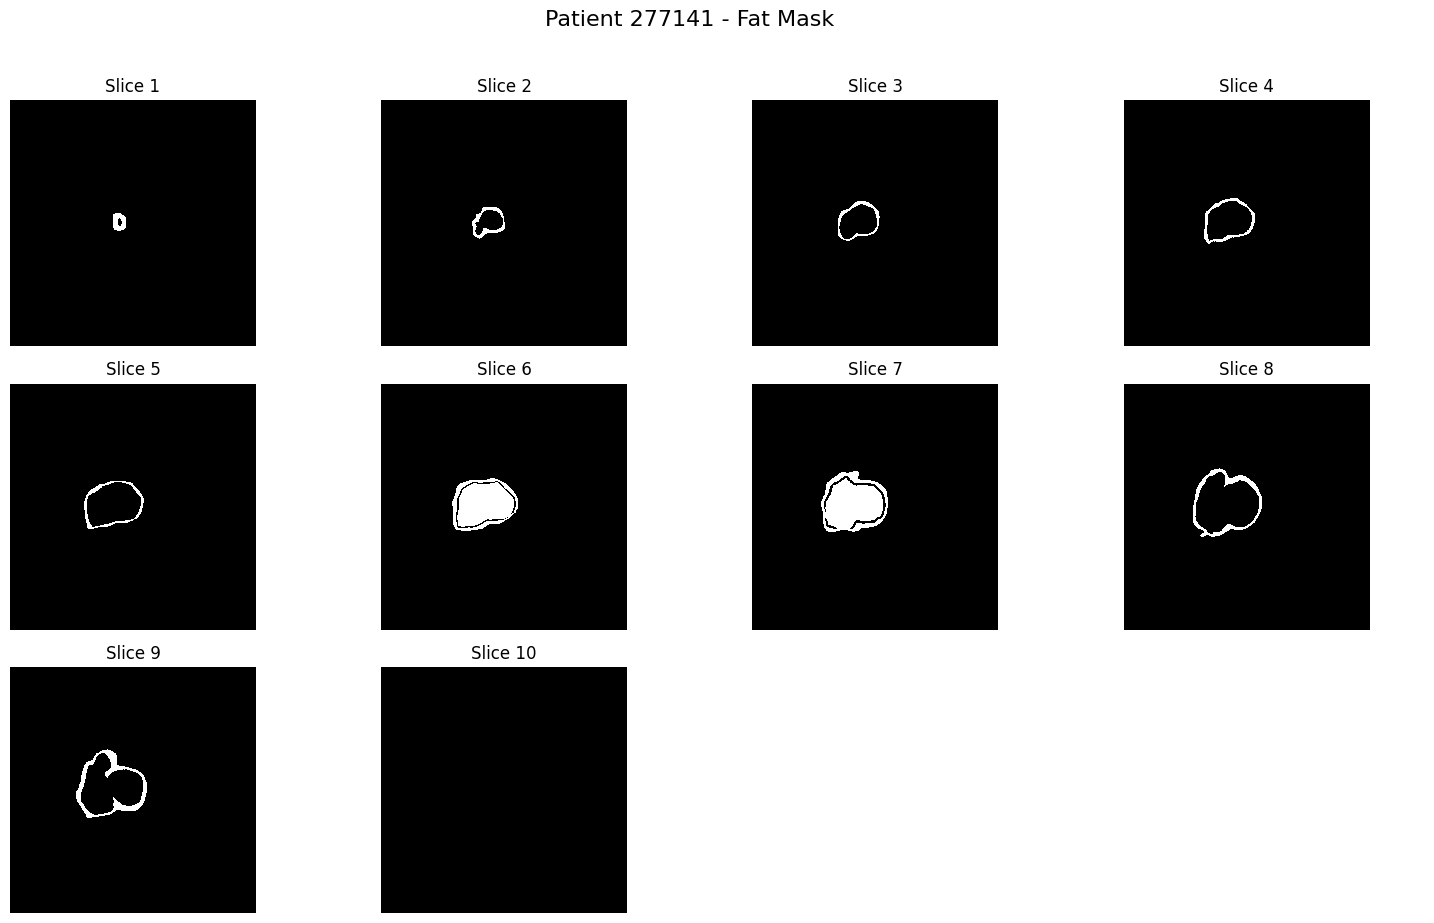

========== Processing Patient: 075197 ==========
{'Original_Mask': '/home/heitor/Documents/masks/075197/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/075197/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/075197/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/075197/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/075197/Volume rendering ROI.mrk.json'}
{'Original_Mask': '/home/heitor/Documents/masks/075197/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/075197/Fat_Segmentation.seg.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/075197/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'Scene_PNG': '/home/heitor/Documents/masks/075197/2026-08-12-Scene.png'}

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (12, 512, 512)
Spacing: (0.8594000000000002, 0.85

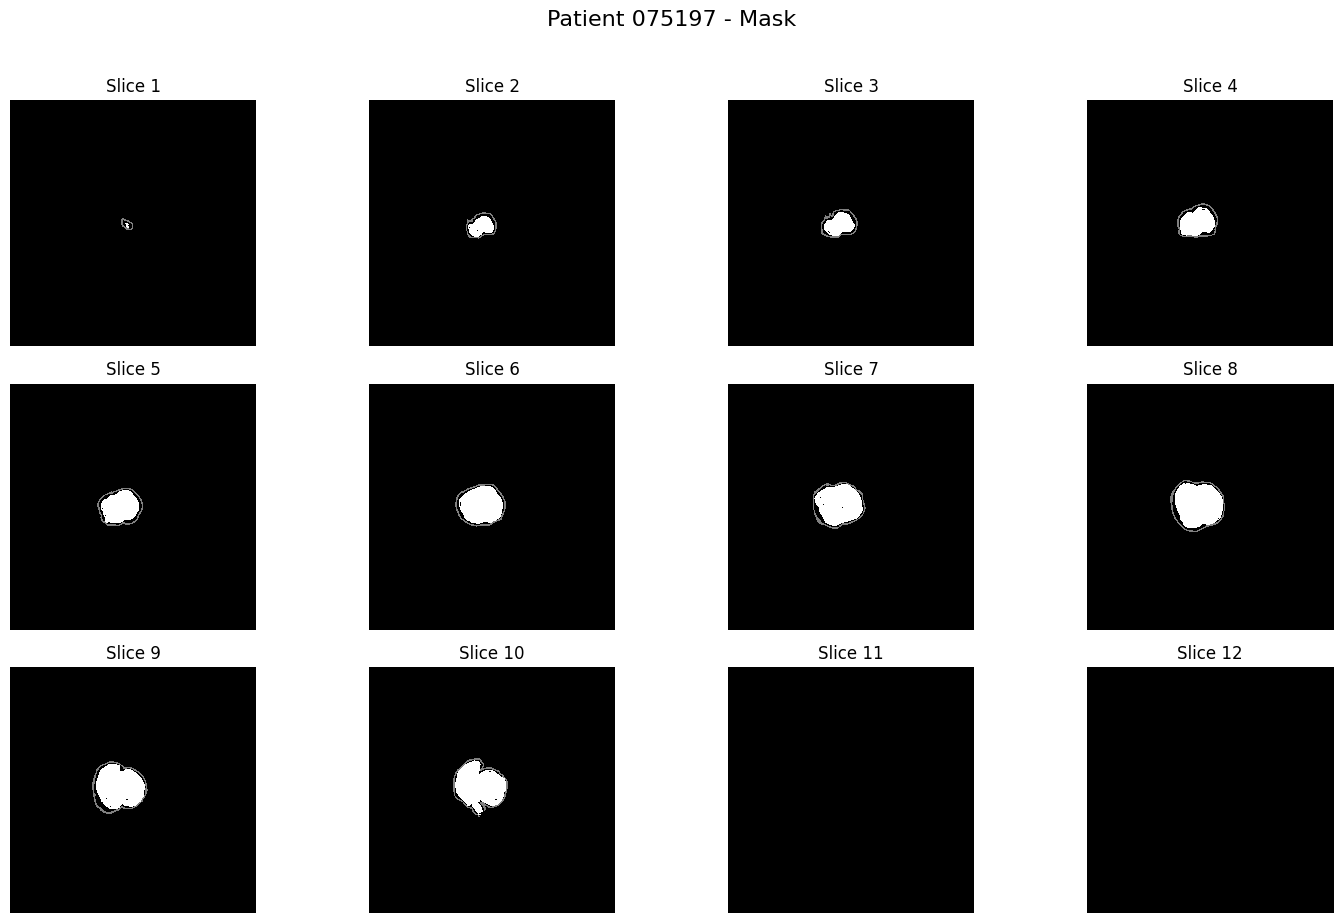


--- Metadata: 3D Segmentation Fat Mask ---
Path: Fat_Segmentation.seg.nrrd
Shape: (12, 512, 512)
Spacing: (0.8594000000000003, 0.8594000000000002, 9.99996465826813)
Unique Labels: [0 1]


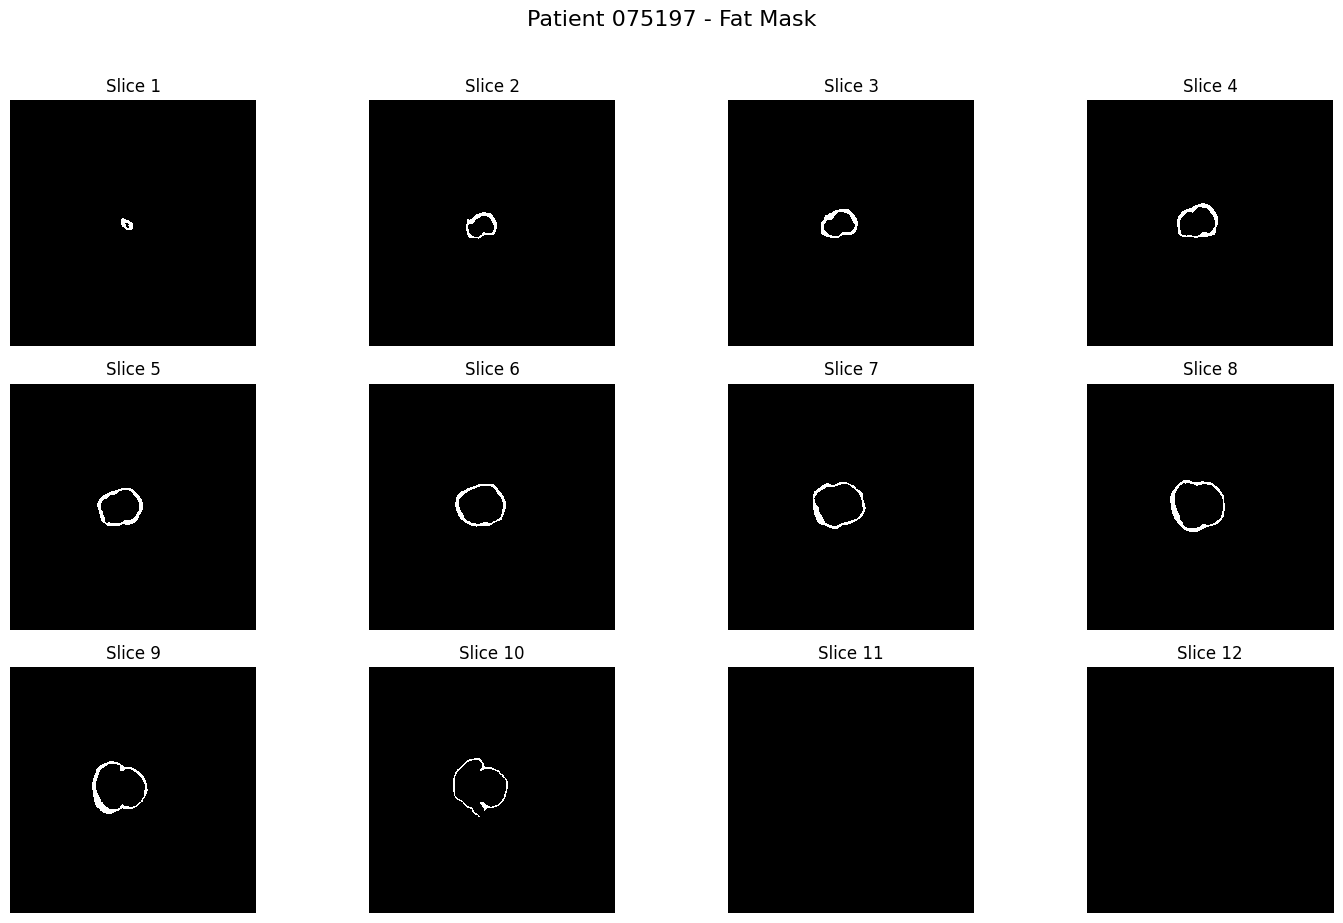

========== Processing Patient: 147230 ==========
{'Original_Mask': '/home/heitor/Documents/masks/147230/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/147230/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/147230/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/147230/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/147230/Volume rendering ROI.mrk.json'}
{'Original_Mask': '/home/heitor/Documents/masks/147230/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/147230/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/147230/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/147230/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'Scene_PNG': '/home/heitor/Documents/masks/147230/2026-08-12-Scene.png'}

--- 

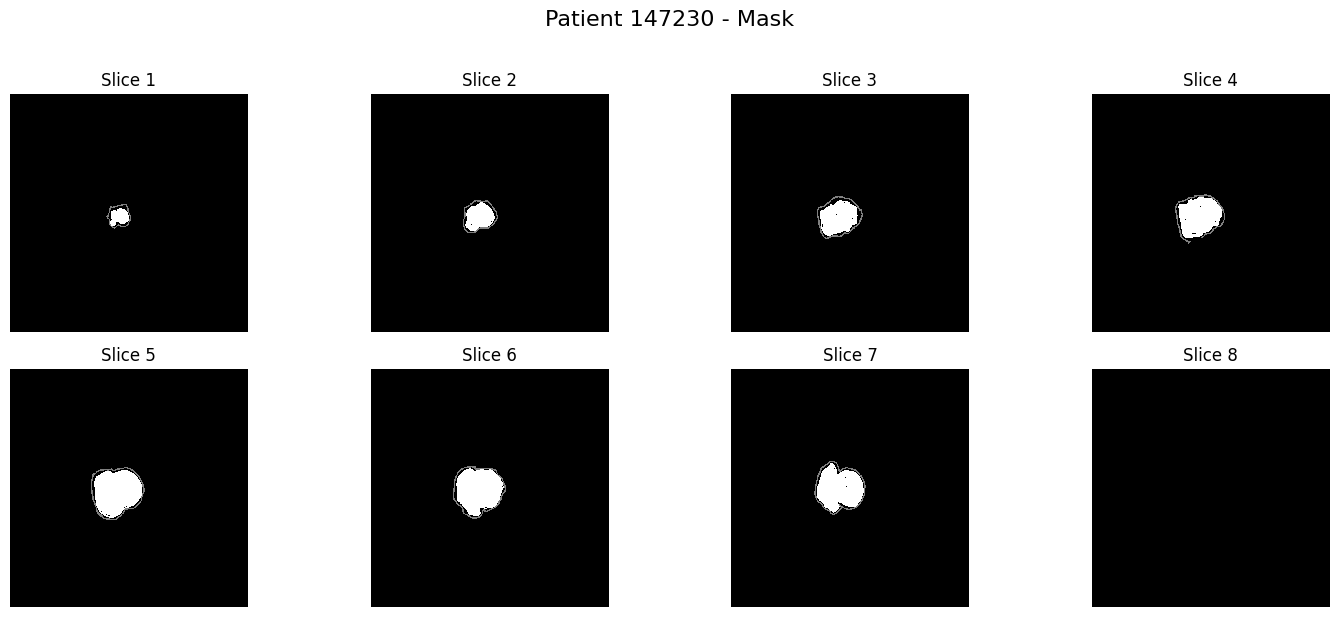


--- Metadata: 3D Segmentation Fat Mask ---
Path: Fat_Segmentation.seg.nrrd
Shape: (8, 512, 512)
Spacing: (0.7813000000000001, 0.7813000000000001, 10.000012126641721)
Unique Labels: [0 1]


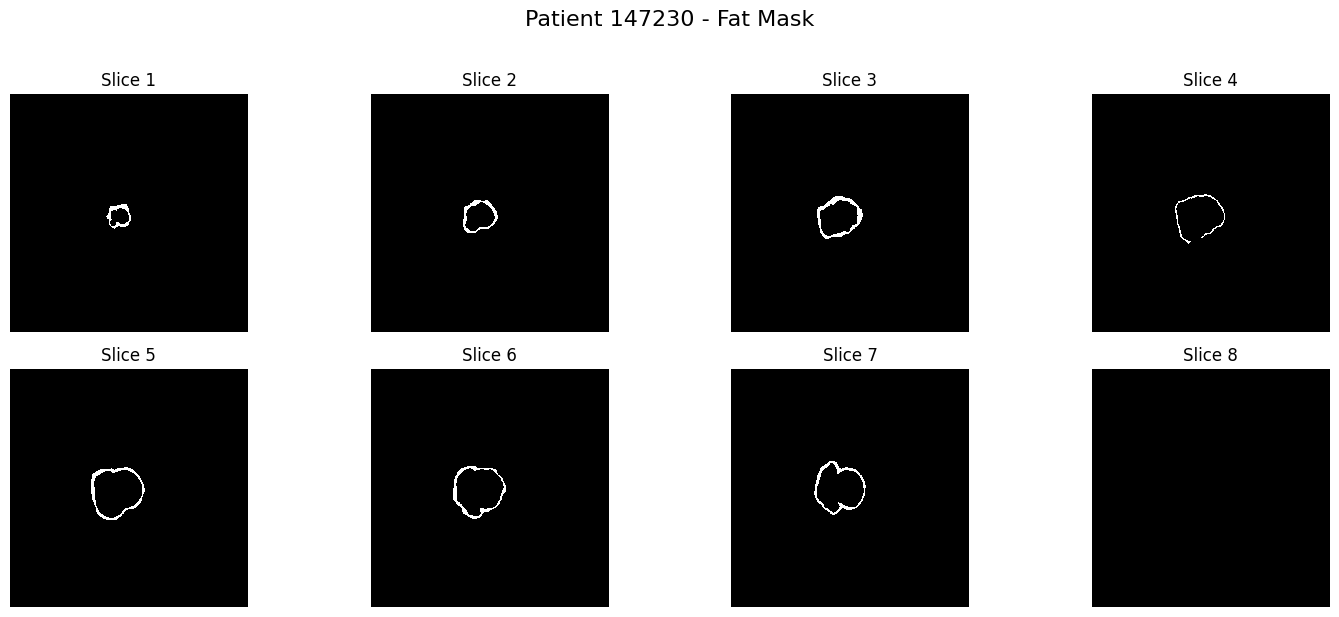

========== Processing Patient: 454328 ==========
{'Original_Mask': '/home/heitor/Documents/masks/454328/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/454328/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/454328/11 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/454328/11 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/454328/Volume rendering ROI.mrk.json'}
{'Original_Mask': '/home/heitor/Documents/masks/454328/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/454328/Fat_Segmentation.seg.nrrd', 'Scene_PNG': '/home/heitor/Documents/masks/454328/2026-08-12-Scene.png'}

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7031, 0.7031000000000003, 10.00002299195505)
Unique Labels: [0 1 2]


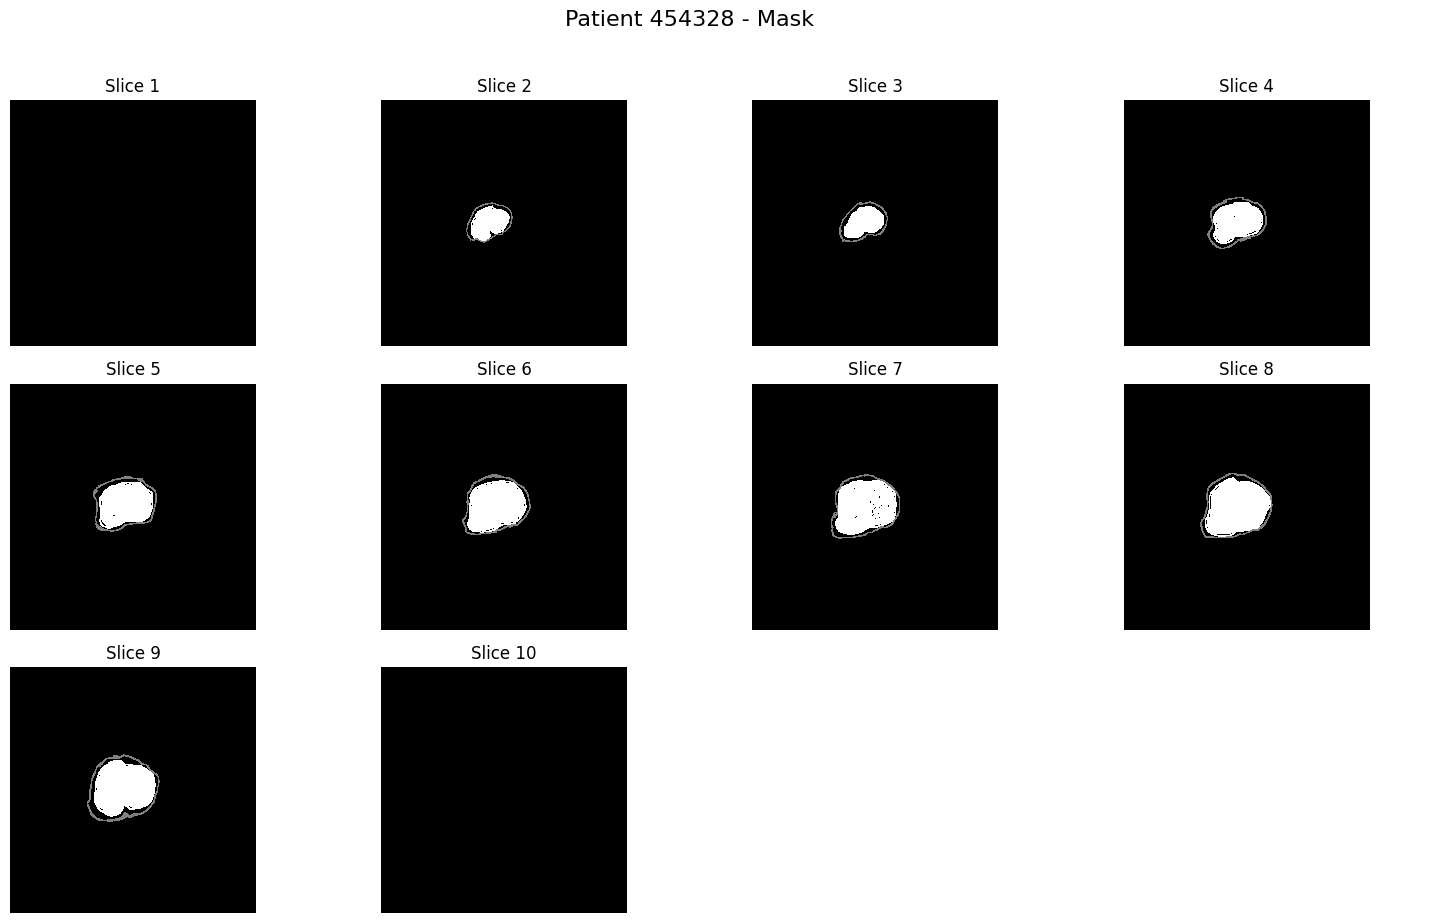


--- Metadata: 3D Segmentation Fat Mask ---
Path: Fat_Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7031, 0.7031000000000003, 10.00002299195505)
Unique Labels: [0 1]


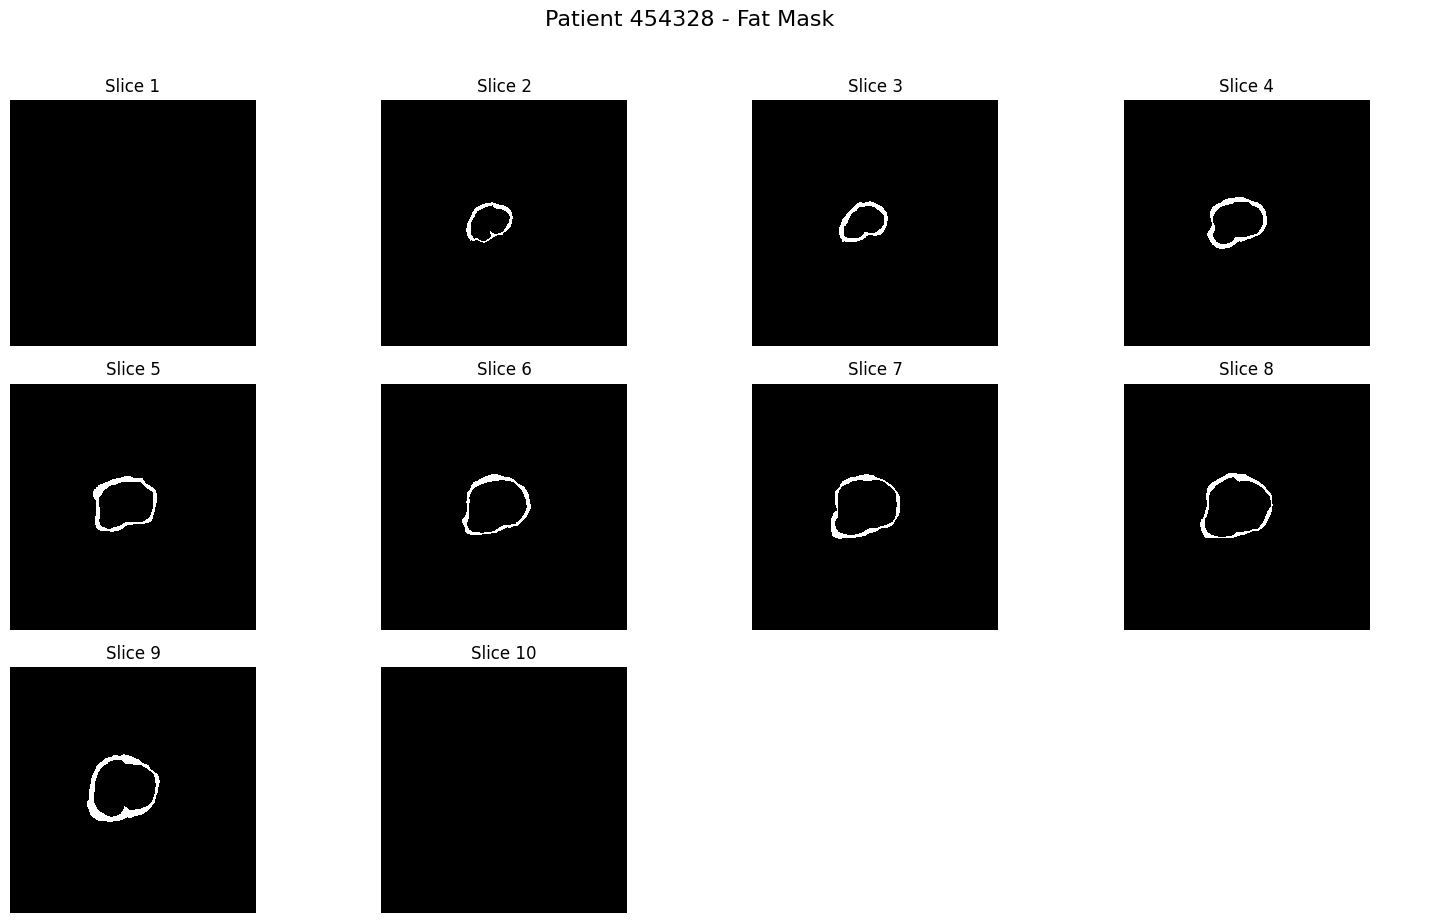

========== Processing Patient: 897528 ==========
{'Original_Mask': '/home/heitor/Documents/masks/897528/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/897528/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/897528/10 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/897528/10 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/897528/Volume rendering ROI.mrk.json'}
{'Original_Mask': '/home/heitor/Documents/masks/897528/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/897528/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/897528/10 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/897528/10 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'Scene_PNG': '/home/heitor/Documents/masks/897528/2026-08-12-Scene.png'}

--- 

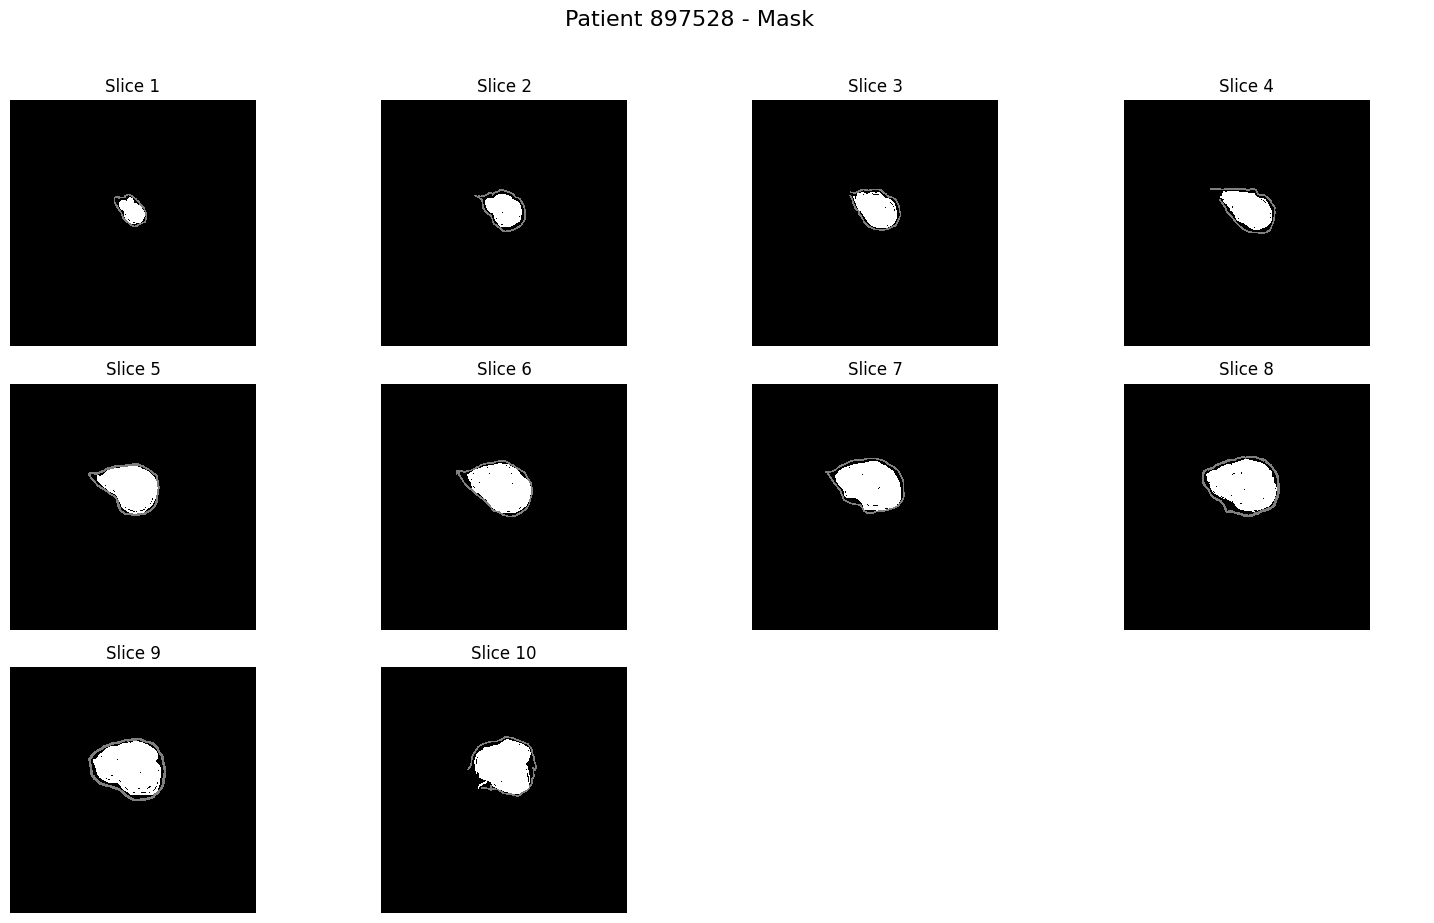


--- Metadata: 3D Segmentation Fat Mask ---
Path: Fat_Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.8203000000000001, 0.8202999999999999, 9.999984397088133)
Unique Labels: [0 1]


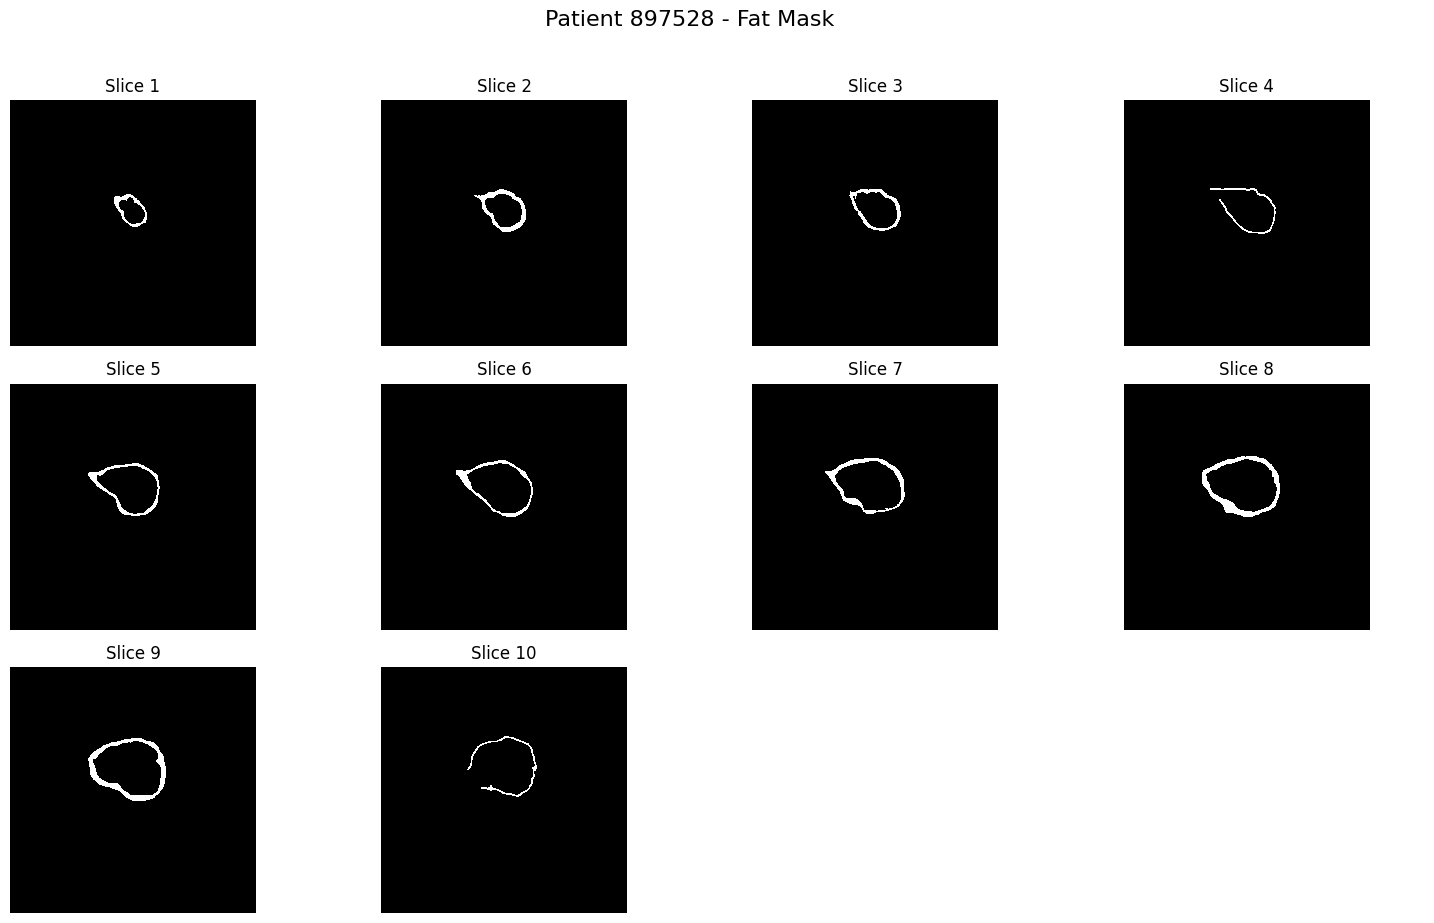

========== Processing Patient: 085837 ==========
{'Original_Mask': '/home/heitor/Documents/masks/085837/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/085837/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/085837/17 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/085837/17 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/085837/Volume rendering ROI.mrk.json'}
{'Original_Mask': '/home/heitor/Documents/masks/085837/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/085837/Fat_Segmentation.seg.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/085837/17 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'Scene_PNG': '/home/heitor/Documents/masks/085837/2026-08-12-Scene.png'}

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7813, 0.78130000000000

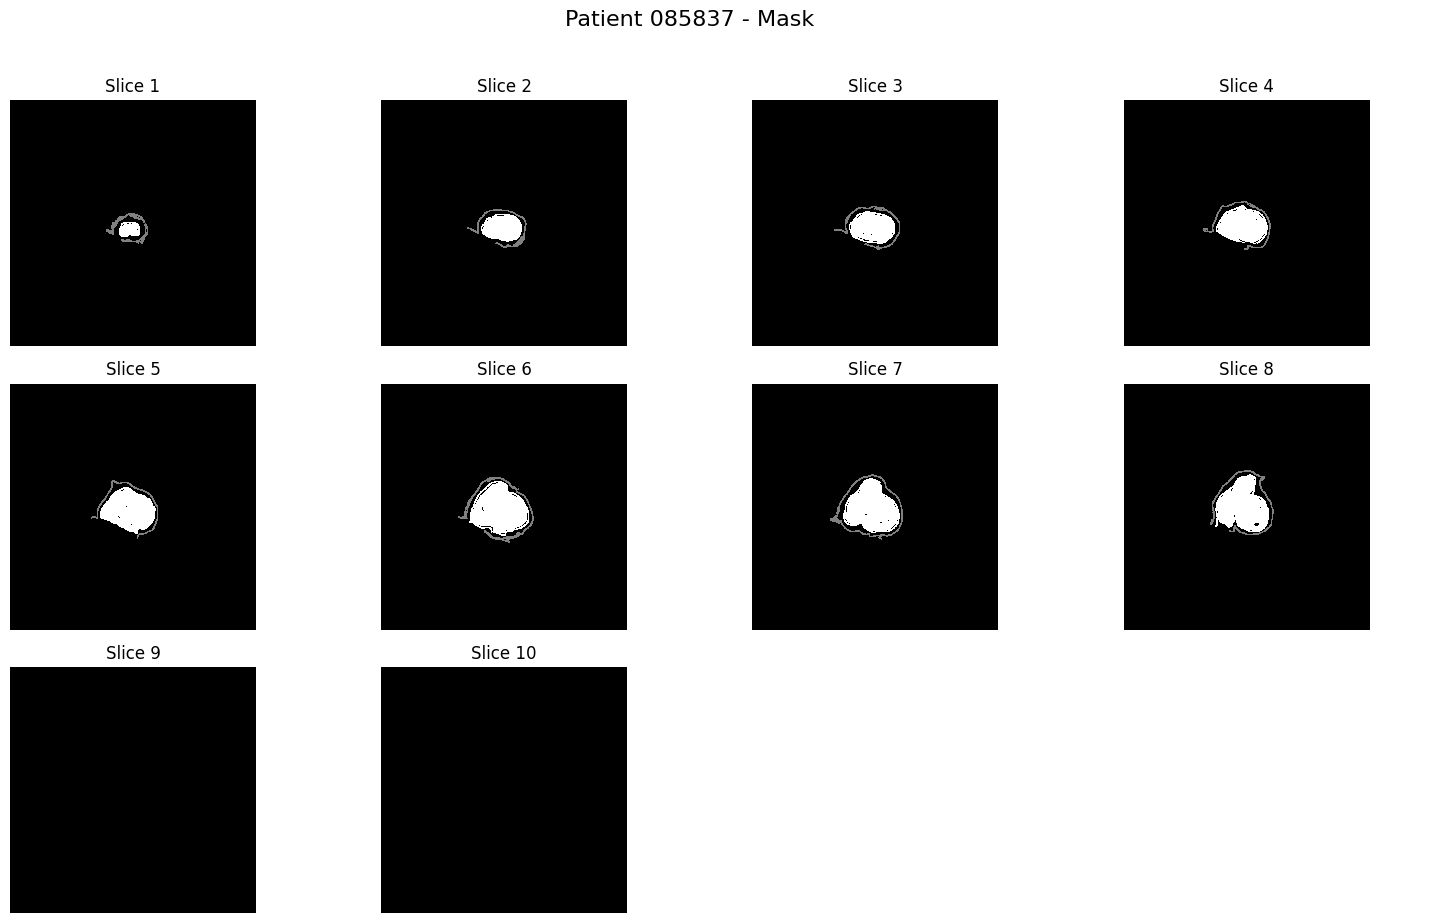


--- Metadata: 3D Segmentation Fat Mask ---
Path: Fat_Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7813, 0.7813000000000001, 10.000066821900198)
Unique Labels: [0 1]


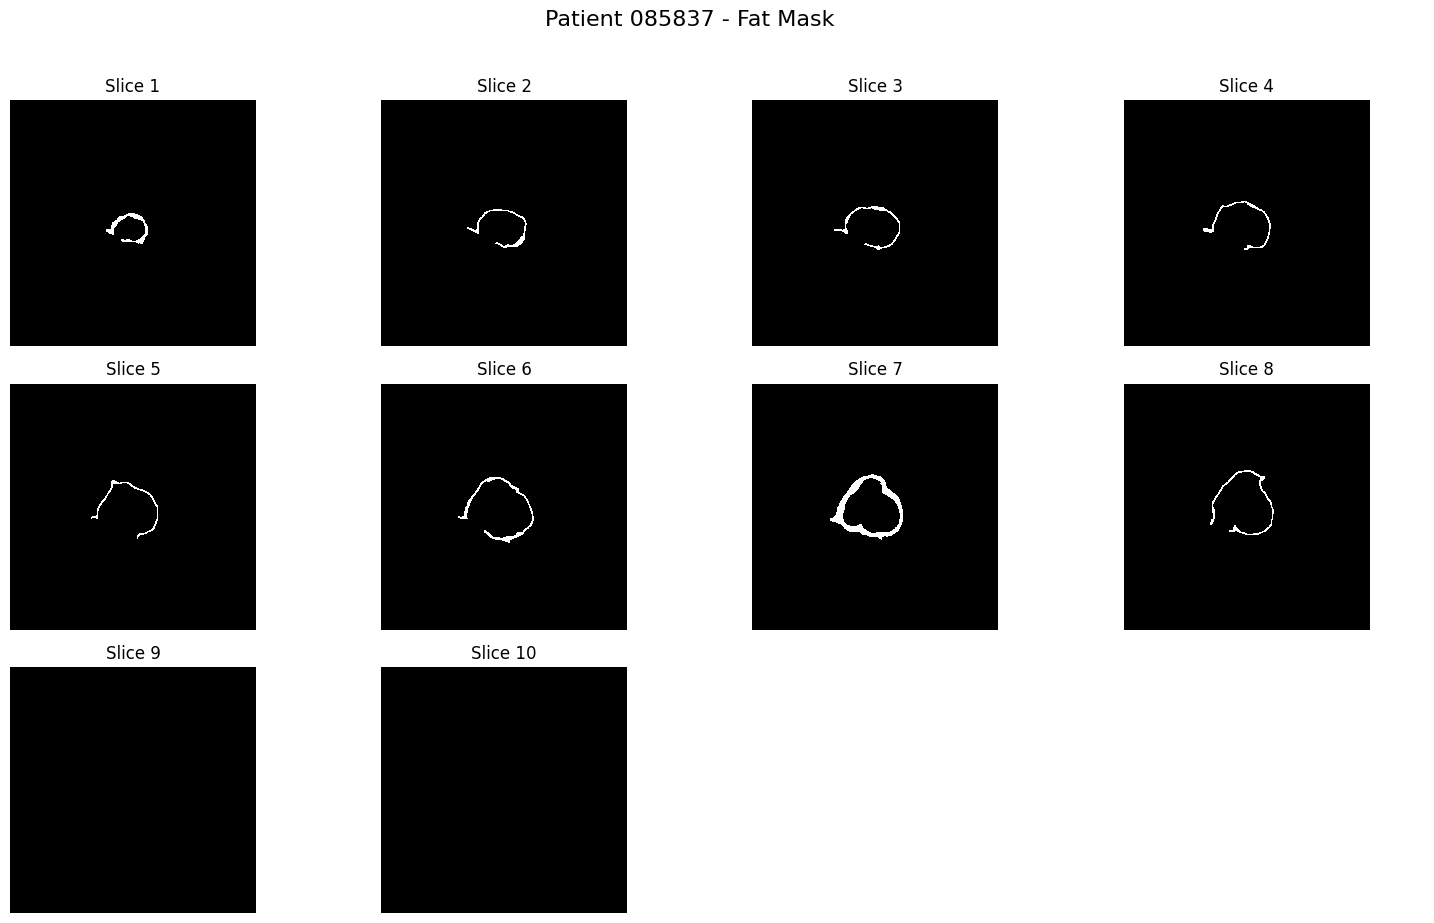

========== Processing Patient: 500677 ==========
{'Original_Mask': '/home/heitor/Documents/masks/500677/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/500677/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/500677/20 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/500677/20 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/500677/Volume rendering ROI.mrk.json'}
{'Original_Mask': '/home/heitor/Documents/masks/500677/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/500677/Fat_Segmentation.seg.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/500677/20 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'Scene_PNG': '/home/heitor/Documents/masks/500677/2026-08-12-Scene.png'}

--- Metadata: 3D Segmentation Mask ---
Path: Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7031, 0.7031, 10.00005

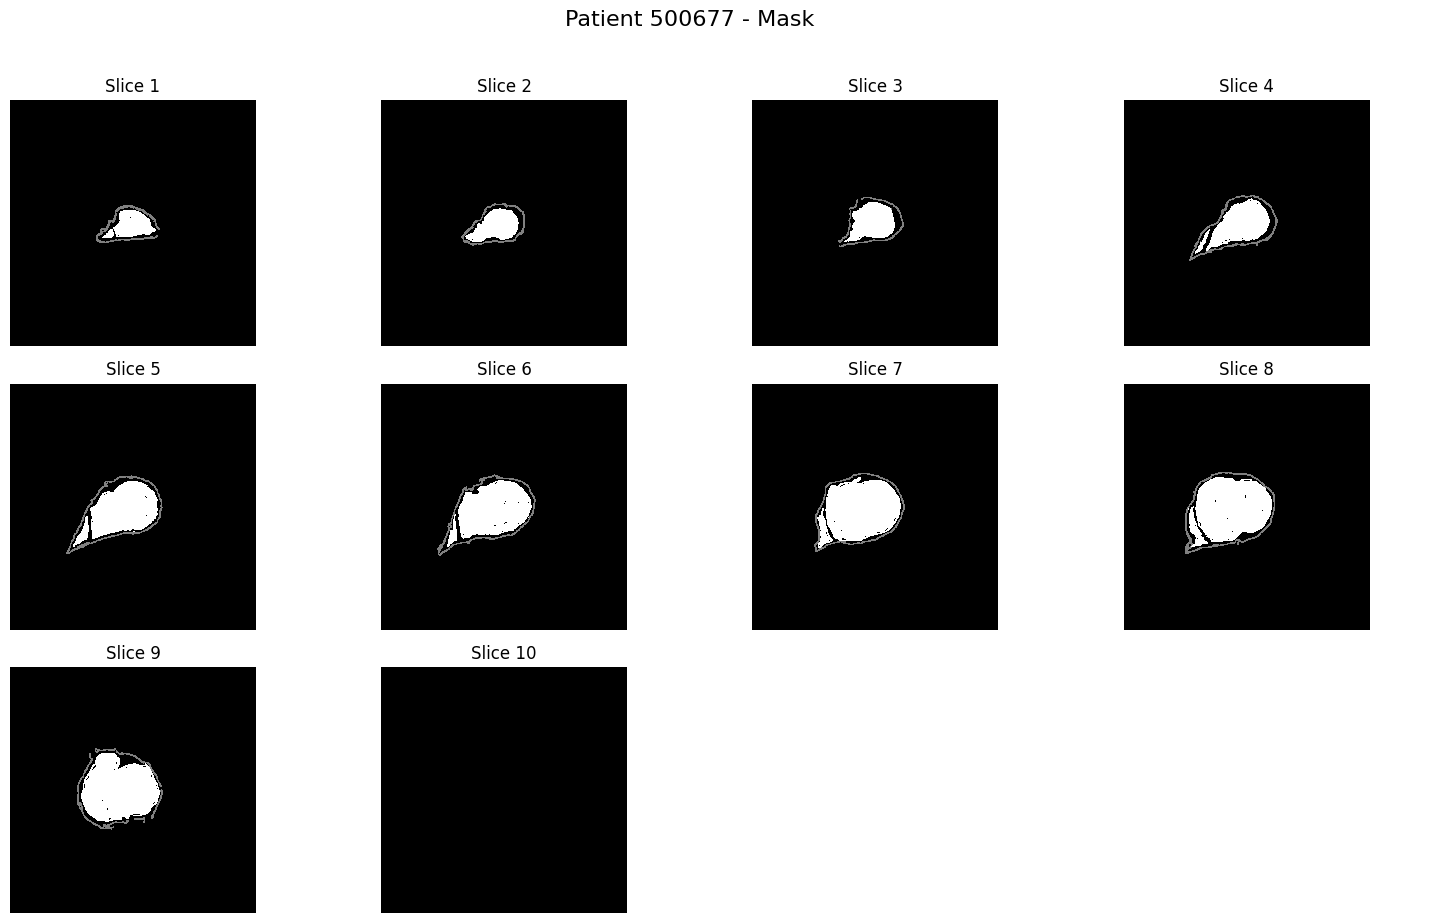


--- Metadata: 3D Segmentation Fat Mask ---
Path: Fat_Segmentation.seg.nrrd
Shape: (10, 512, 512)
Spacing: (0.7031, 0.7031, 10.00005195942674)
Unique Labels: [0 1]


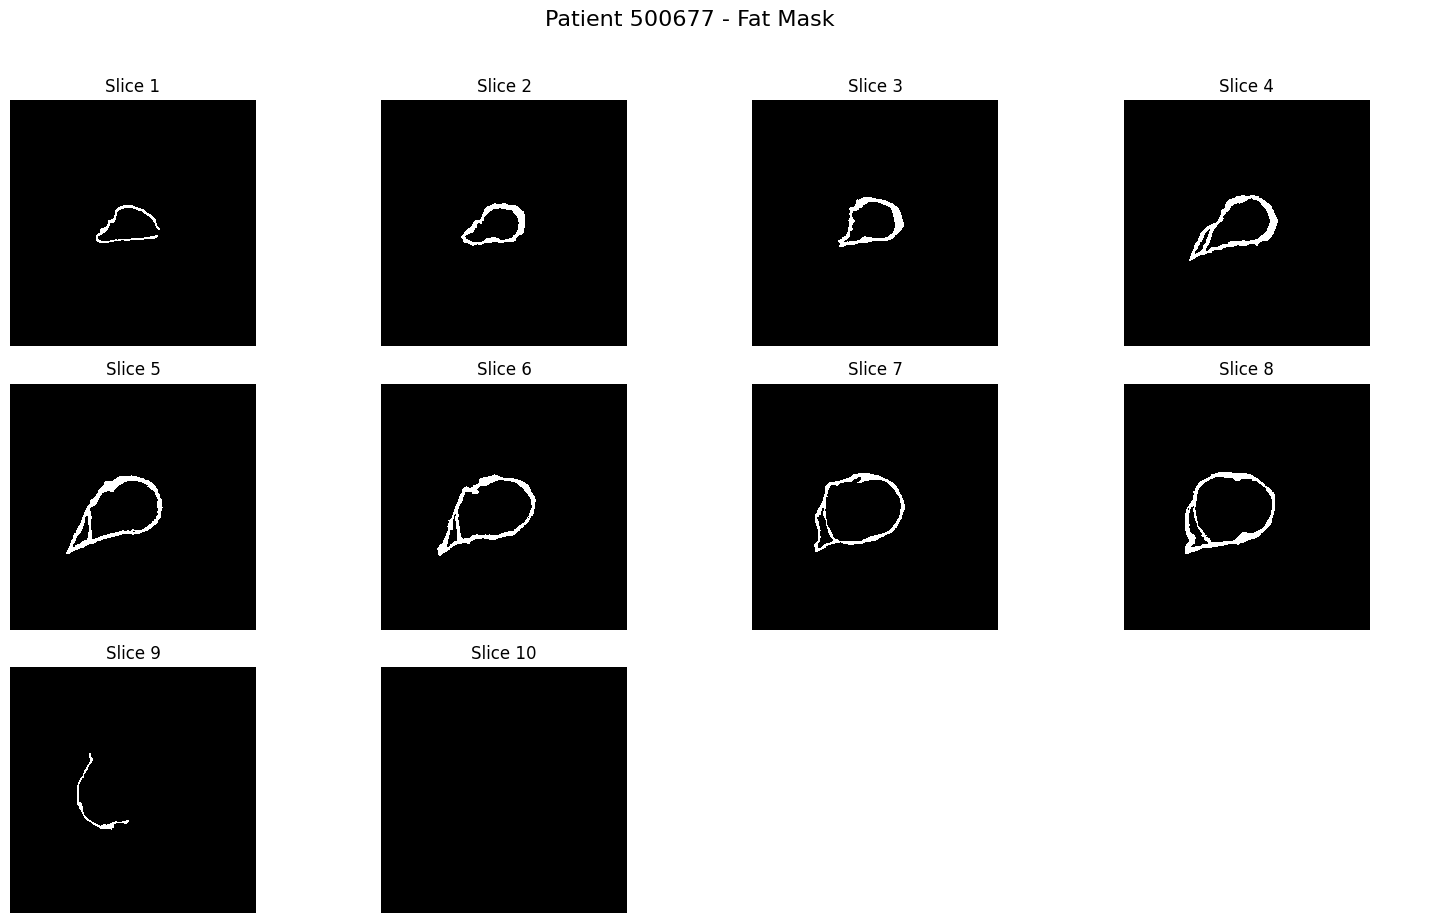

========== Processing Patient: 308512 ==========
{'Original_Mask': '/home/heitor/Documents/masks/308512/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/308512/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/308512/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/308512/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'JSON': '/home/heitor/Documents/masks/308512/Volume rendering ROI.mrk.json'}
{'Original_Mask': '/home/heitor/Documents/masks/308512/Segmentation.seg.nrrd', 'Fat_Mask': '/home/heitor/Documents/masks/308512/Fat_Segmentation.seg.nrrd', 'Frame_19': '/home/heitor/Documents/masks/308512/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber 19.nrrd', 'Sequence_4D': '/home/heitor/Documents/masks/308512/14 MR CINE EC - 20 frames Volume Sequence by InstanceNumber.seq.nrrd', 'Scene_PNG': '/home/heitor/Documents/masks/308512/2026-08-12-Scene.png'}

--- 

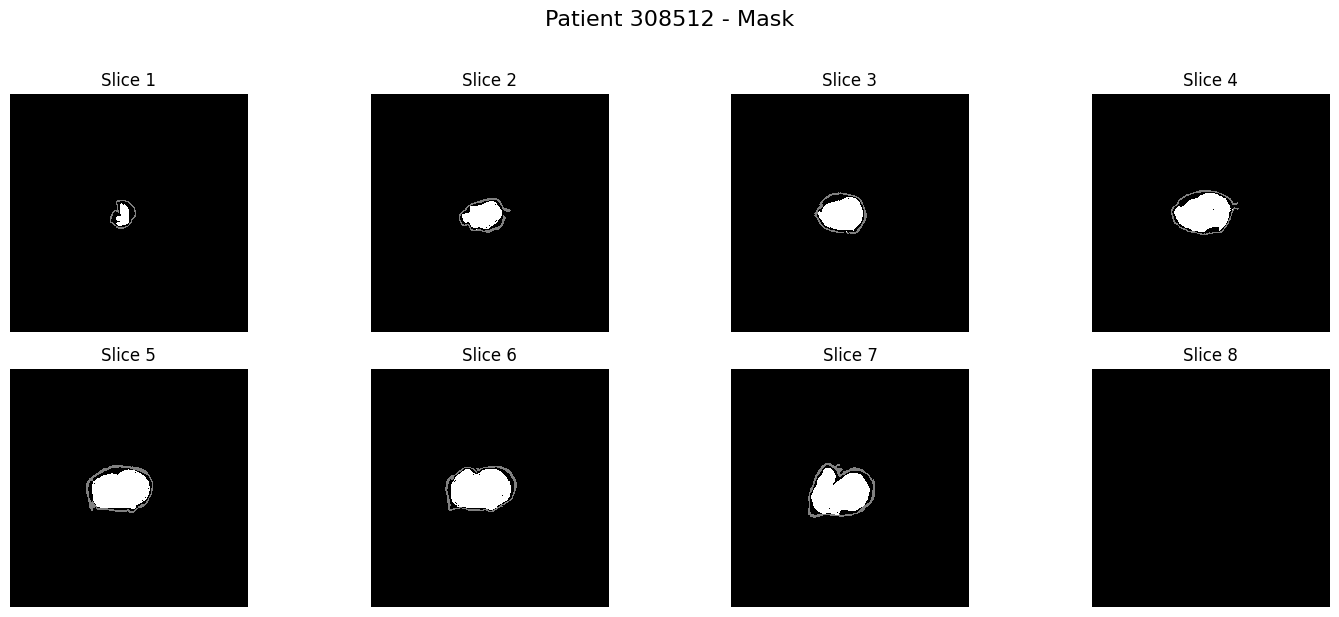


--- Metadata: 3D Segmentation Fat Mask ---
Path: Fat_Segmentation.seg.nrrd
Shape: (8, 512, 512)
Spacing: (0.8594000000000002, 0.8594000000000003, 10.000002646132303)
Unique Labels: [0 1]


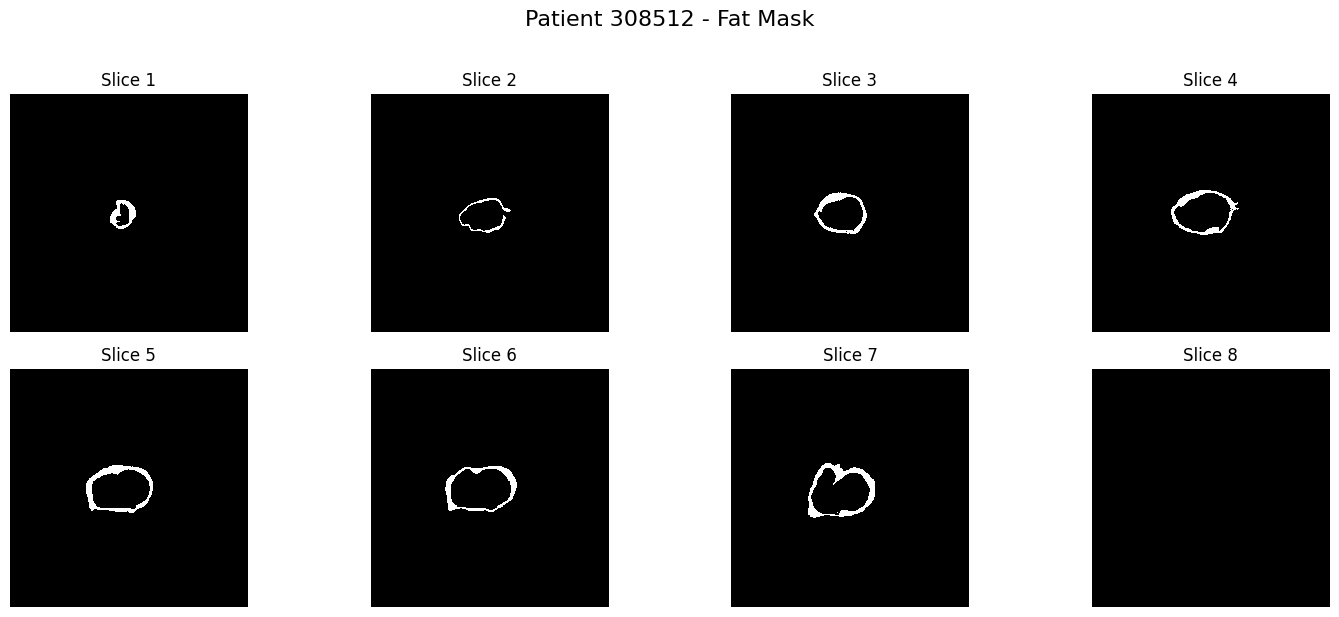

In [70]:
for (patient, (study, num_dcm)) in mri_dataset_info.items():    
    process_patient(patient, study)